## Dim Macroeconómica

In [2]:
import pandas as pd
import glob
import os

ruta = r'C:\Users\lulaz\Desktop\IT Academy - Data Analysis\Proyecto Especialización\Indicadores\1b. Indicadores Macroeconomicos excell a csv'
archivos_csv = glob.glob(os.path.join(ruta, '*.csv'))

# Diccionario para guardar los dataframes con nombre de archivo como clave
dfs_dict = {}

for archivo in archivos_csv:
    nombre = os.path.basename(archivo)  # solo el nombre del archivo, sin ruta
    df = pd.read_csv(archivo)
    dfs_dict[nombre] = df

# Ahora podés acceder así:
dfs_dict['Exports of goods and services (current US$).csv']


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,"2158564245,81006","2142859776,53631","2243516759,77654","2367134078,21229","2486899441,34078","1315200705,39372","2072291765,39888","2871730317,57014","3223287659,08212",NaN
1,Africa Eastern and Southern,AFE,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,"216730710797,857","193247455276,201","224378709635,18","257148832020,761","242118378709,749","206363450018,775","282463209664,023","329207394352,552","303251837815,133",NaN
2,Afghanistan,AFG,Exports of goods and services (current US$),NE.EXP.GNFS.CD,"22222233,3333333","24444455,5555556",26666680,"68888922,2222222","71111144,4444445",113333340,...,NaN,NaN,NaN,NaN,NaN,"2079570874,83738","2045190335,08092","2664599570,76697","2890867894,87049",NaN
3,Africa Western and Central,AFW,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,"26926846081,4949","14838933358,413","21373167719,7176","32444713329,5102","28919814315,7895","18583150428,118","31753057845,2236","46344761973,8705","34656621950,2738",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,"1413505662,95645","1592308569,31597","1962420046,85915","2289052674,09329","2315619066,38484","1674245989,91424","3144941251,06314","3613392770,75998","4149652323,43113",NaN
262,"Yemen, Rep.",YEM,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,"3841895882,94859","1506135198,53953","2600533661,65587","1891748346,76607",NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,Exports of goods and services (current US$),NE.EXP.GNFS.CD,"2238599104,56036","2337999064,80037","2498999000,4004","2696398921,44043","2846198861,52046","2913398834,64047",...,"96085897668,3633","91109021408,9525","104288394992,827","111434691806,498","105906059178,622","93199600859,2205","130910965845,524","135795104058,468","124696245269,168",NaN
264,Zambia,ZMB,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,"7892388633,94057","7403491271,28836","9053912487,52298","9987165258,55507","8073235065,94259","8473997596,93761","11537884956,0409","11722089926,1135","11264526288,2707",NaN


In [3]:
import pandas as pd
import re

def transformar_indicadores(dfs_dict):
    dfs_transformados = {}

    for nombre_archivo, df in dfs_dict.items():
        try:
            # Obtener el nombre del indicador (asumimos que todas las filas tienen el mismo)
            indicator_name = df['Indicator Name'].iloc[0]

            # Limpiar el nombre del indicador para usar como clave de diccionario
            nombre_limpio = re.sub(r'[^\w]', '_', indicator_name)
            
            

            # Transformar a formato largo
            df_largo = df.melt(
                id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
                var_name='Year',
                value_name='Value'
            )

            # Renombrar columnas
            df_largo = df_largo.rename(columns={
                'Country Name': 'Country',
                'Indicator Name': 'Indicator',
                'Indicator Code': 'Indicator Code'
            })

            # Reordenar columnas
            df_largo = df_largo[['Indicator Code', 'Indicator', 'Country', 'Year', 'Value']]

            # Guardar el DataFrame transformado en el nuevo diccionario
            dfs_transformados[nombre_limpio] = df_largo

            print(f"✅ Transformado: '{indicator_name}' → clave: '{nombre_limpio}'")

        except Exception as e:
            print(f"❌ Error al procesar {nombre_archivo}: {e}")

    return dfs_transformados



In [15]:
dfs_transformados = transformar_indicadores(dfs_dict)
dfs_transformados

✅ Transformado: 'Exports of goods and services (current US$)' → clave: 'Exports_of_goods_and_services__current_US__'
✅ Transformado: 'GDP (current US$)' → clave: 'GDP__current_US__'
✅ Transformado: 'GDP per capita (current US$)' → clave: 'GDP_per_capita__current_US__'
✅ Transformado: 'Gross capital formation (current US$)' → clave: 'Gross_capital_formation__current_US__'
✅ Transformado: 'Imports of goods and services (current US$)' → clave: 'Imports_of_goods_and_services__current_US__'
✅ Transformado: 'Inflation, consumer prices (annual %)' → clave: 'Inflation__consumer_prices__annual___'
✅ Transformado: 'Listed domestic companies, total' → clave: 'Listed_domestic_companies__total'


{'Exports_of_goods_and_services__current_US__':        Indicator Code                                    Indicator  \
 0      NE.EXP.GNFS.CD  Exports of goods and services (current US$)   
 1      NE.EXP.GNFS.CD  Exports of goods and services (current US$)   
 2      NE.EXP.GNFS.CD  Exports of goods and services (current US$)   
 3      NE.EXP.GNFS.CD  Exports of goods and services (current US$)   
 4      NE.EXP.GNFS.CD  Exports of goods and services (current US$)   
 ...               ...                                          ...   
 17285  NE.EXP.GNFS.CD  Exports of goods and services (current US$)   
 17286  NE.EXP.GNFS.CD  Exports of goods and services (current US$)   
 17287  NE.EXP.GNFS.CD  Exports of goods and services (current US$)   
 17288  NE.EXP.GNFS.CD  Exports of goods and services (current US$)   
 17289  NE.EXP.GNFS.CD  Exports of goods and services (current US$)   
 
                            Country  Year             Value  
 0                            Aruba  

In [16]:

#creamos los dataframes por cada indicador y observamos su estructura
gdp= dfs_transformados['GDP__current_US__']
gdp_percapita=dfs_transformados['GDP_per_capita__current_US__']
exports = dfs_transformados['Exports_of_goods_and_services__current_US__']
imports = dfs_transformados['Imports_of_goods_and_services__current_US__']
capital_formation= dfs_transformados['Gross_capital_formation__current_US__']
domestic_companies =dfs_transformados['Listed_domestic_companies__total']
inflation= dfs_transformados['Inflation__consumer_prices__annual___']



In [6]:
gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17290 entries, 0 to 17289
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Indicator Code  17290 non-null  object
 1   Indicator       17290 non-null  object
 2   Country         17290 non-null  object
 3   Year            17290 non-null  object
 4   Value           14307 non-null  object
dtypes: object(5)
memory usage: 675.5+ KB


In [20]:

#Unificamos los DF
df_all = pd.concat([gdp, gdp_percapita, exports, imports, capital_formation, domestic_companies, inflation], ignore_index=True)

#Eliminamos tablas que no vamos a utilizar
df_all = df_all.drop(columns=['Indicator Code'])

# 1. Reemplazá las comas decimales por puntos
df_all['Value'] = df_all['Value'].astype(str).str.replace(',', '.', regex=False)

# 2. Convertí a número, forzando NaN en errores
df_all['Value'] = pd.to_numeric(df_all['Value'], errors='coerce')

#se pivotea el dataframe para tener un valor por indicador
df_wide = df_all.pivot_table(
    index=['Country', 'Year'],
    columns='Indicator',
    values='Value').reset_index()





In [21]:
df_wide

Indicator,Country,Year,Exports of goods and services (current US$),GDP (current US$),GDP per capita (current US$),Gross capital formation (current US$),Imports of goods and services (current US$),"Inflation, consumer prices (annual %)","Listed domestic companies, total"
0,Afghanistan,1960,2.222223e+07,NaN,NaN,8.666671e+07,3.777778e+07,NaN,NaN
1,Afghanistan,1961,2.444446e+07,NaN,NaN,9.111116e+07,4.444445e+07,NaN,NaN
2,Afghanistan,1962,2.666668e+07,NaN,NaN,1.044445e+08,5.111111e+07,NaN,NaN
3,Afghanistan,1963,6.888892e+07,NaN,NaN,1.066667e+08,1.266667e+08,NaN,NaN
4,Afghanistan,1964,7.111114e+07,NaN,NaN,1.111112e+08,1.444445e+08,NaN,NaN
...,...,...,...,...,...,...,...,...,...
14619,Zimbabwe,2019,7.086215e+09,2.571741e+10,1684.027904,3.548836e+09,7.263061e+09,255.304991,NaN
14620,Zimbabwe,2020,5.989686e+09,2.686794e+10,1730.413489,3.532081e+09,6.722439e+09,557.201817,NaN
14621,Zimbabwe,2021,6.204093e+09,2.724052e+10,1724.387731,4.224202e+09,7.646927e+09,98.546105,NaN
14622,Zimbabwe,2022,9.139216e+09,3.278975e+10,2040.552459,4.790694e+09,1.209661e+10,104.705171,NaN


In [22]:

ordered_columns = [
    'Country', 'Year',
    'GDP (current US$)',
    'GDP per capita (current US$)',
    'Exports of goods and services (current US$)',
    'Imports of goods and services (current US$)',
    'Gross capital formation (current US$)',
    'Inflation, consumer prices (annual %)',
    'Listed domestic companies, total'
]

# Ahora reasignás las columnas al DataFrame
df_wide = df_wide[ordered_columns]

df_wide.columns=[
    'Country', 'Year',
    'GDP',
    'GDP per capita',
    'Exports',
    'Imports',
    'Gross capital formation',
    'Inflation',
    'Listed domestic companies'
]

df_wide

df_wide[df_wide['Country'].isin(['Venezuela, RB'])]

,Country,Year,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies
14250,"Venezuela, RB",1960,7.663938e+09,939.197767,2.332410e+09,1.390889e+09,1.882891e+09,NaN,NaN
14251,"Venezuela, RB",1961,8.067267e+09,954.038331,2.558575e+09,1.366605e+09,1.919946e+09,NaN,NaN
14252,"Venezuela, RB",1962,8.814310e+09,1006.559408,2.880107e+09,1.489969e+09,2.119345e+09,NaN,NaN
14253,"Venezuela, RB",1963,9.608717e+09,1060.094332,3.078814e+09,1.458862e+09,2.146781e+09,NaN,NaN
14254,"Venezuela, RB",1964,8.192414e+09,873.604755,2.471908e+09,1.473655e+09,2.376805e+09,NaN,NaN
14255,"Venezuela, RB",1965,8.427778e+09,869.041068,2.451467e+09,1.612822e+09,2.356867e+09,NaN,NaN
14256,"Venezuela, RB",1966,8.781333e+09,875.956232,2.429978e+09,1.505289e+09,2.393422e+09,NaN,NaN
14257,"Venezuela, RB",1967,9.250000e+09,892.985316,2.516000e+09,1.612822e+09,2.485889e+09,NaN,NaN
14258,"Venezuela, RB",1968,1.003444e+10,938.015079,2.537489e+09,1.956889e+09,3.257889e+09,NaN,NaN
14259,"Venezuela, RB",1969,1.028511e+10,931.598756,2.516000e+09,2.042889e+09,3.494422e+09,NaN,NaN


In [23]:
df_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14624 entries, 0 to 14623
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    14624 non-null  object 
 1   Year                       14624 non-null  object 
 2   GDP                        14307 non-null  float64
 3   GDP per capita             14312 non-null  float64
 4   Exports                    11063 non-null  float64
 5   Imports                    11085 non-null  float64
 6   Gross capital formation    10593 non-null  float64
 7   Inflation                  11182 non-null  float64
 8   Listed domestic companies  4096 non-null   float64
dtypes: float64(7), object(2)
memory usage: 1.0+ MB


### CSV Dim_Macroeconómica

In [24]:
# CONVERTIR EN CSV entendiendo que el decimal es con , (importante!)
df_wide.to_csv('dim_macroeconomica_v1.csv', decimal=',', index=False)

In [112]:
Latam_macro=df_wide[df_wide['Country'].isin(['Argentina', 'Bolivia', 'Brazil','Chile','Colombia', 'Costa Rica','Dominican Republic','Ecuador', 'El Salvador','Guatemala', 'Honduras', 'Mexico', 'Panama','Paraguay', 'Peru','Uruguay', 
                         'Venezuela, RB'  ])]

Latam_macro["Year"] = Latam_macro["Year"].astype(int)

Latam_macro=Latam_macro[Latam_macro["Year"] >= 1990]
Latam_macro.head()

C:\Users\lulaz\AppData\Local\Temp\ipykernel_44296\465624202.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Country,Year,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies
540,Argentina,1990,1.413526e+11,4315.333294,1.464348e+10,6.546496e+09,1.978510e+10,NaN,178.0
541,Argentina,1991,1.897200e+11,5709.247841,1.456109e+10,1.153120e+10,2.776927e+10,NaN,169.0
542,Argentina,1992,2.287789e+11,6789.996111,1.509526e+10,1.860612e+10,3.821158e+10,NaN,170.0
543,Argentina,1993,2.367417e+11,6931.855964,1.635732e+10,2.204965e+10,4.660997e+10,NaN,165.0
544,Argentina,1994,2.574400e+11,7437.562423,1.938510e+10,2.729996e+10,5.139950e+10,NaN,156.0


### Componentes principales macroeconomicas

In [27]:
columnas = Latam_macro.columns.tolist()
print(columnas)

['Country', 'Year', 'GDP', 'GDP per capita', 'Exports', 'Imports', 'Gross capital formation', 'Inflation', 'Listed domestic companies']


In [28]:


macro = ['GDP', 'GDP per capita', 'Exports', 'Imports', 'Gross capital formation', 'Inflation', 'Listed domestic companies']
macro_var_numericas_latam = Latam_macro[macro]
macro_var_numericas_latam



,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies
540,1.413526e+11,4315.333294,1.464348e+10,6.546496e+09,1.978510e+10,NaN,178.0
541,1.897200e+11,5709.247841,1.456109e+10,1.153120e+10,2.776927e+10,NaN,169.0
542,2.287789e+11,6789.996111,1.509526e+10,1.860612e+10,3.821158e+10,NaN,170.0
543,2.367417e+11,6931.855964,1.635732e+10,2.204965e+10,4.660997e+10,NaN,165.0
544,2.574400e+11,7437.562423,1.938510e+10,2.729996e+10,5.139950e+10,NaN,156.0
...,...,...,...,...,...,...,...
14302,3.812862e+11,12901.417158,9.978648e+10,9.239539e+10,1.014097e+11,21.068996,41.0
14303,3.710054e+11,12403.146696,9.187940e+10,1.094940e+11,1.011693e+11,40.639428,39.0
14304,4.823593e+11,15943.612720,8.052423e+10,1.514463e+11,1.196743e+11,62.168650,37.0
14305,NaN,NaN,NaN,NaN,NaN,121.738085,NaN


In [34]:
#ESTADARIZACIÓN

from sklearn.preprocessing import StandardScaler
scaler= StandardScaler(with_mean=True, with_std=True)
macro_para_pca_std=scaler.fit_transform(macro_var_numericas_latam)
macro_para_pca_std

array([[-0.17112163, -0.31003044, -0.34828826, ..., -0.28642324,
                nan,  0.20864758],
       [-0.05369105,  0.0150589 , -0.34922256, ..., -0.19093197,
                nan,  0.13826981],
       [ 0.04113972,  0.26711148, -0.34316479, ..., -0.06604114,
                nan,  0.14608956],
       ...,
       [ 0.65680487,  2.40192186,  0.39883281, ...,  0.90825935,
         0.05851337, -0.8939376 ],
       [        nan,         nan,         nan, ...,         nan,
         0.21915548,         nan],
       [        nan,         nan,         nan, ...,         nan,
         0.57838681,         nan]], shape=(586, 7))

In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Suponiendo que macro_para_pca ya tiene la columna 'Country'
# 1. Guardamos la columna 'Country' si querés usarla después
paises = Latam_macro['Country']

# 2. Nos quedamos con las columnas numéricas
macro_numerico = Latam_macro.drop(columns=['Country'])

# 3. Rellenamos NaN con la media
macro_numerico = macro_numerico.fillna(macro_numerico.mean())

# 4. Estandarizamos
scaler = StandardScaler()
macro_std = scaler.fit_transform(macro_numerico)

# 5. Aplicamos PCA
pca = PCA(n_components=2)
macro_pca = pca.fit_transform(macro_std)

# 6. Creamos DataFrame con resultados
df_pca = pd.DataFrame(macro_pca, columns=['PC1', 'PC2'])
df_pca['Country'] = paises.values  # Reagregamos los países si hace falta

df_pca


,PC1,PC2,Country
0,-0.946394,-1.160428,Argentina
1,-0.731055,-0.928495,Argentina
2,-0.498978,-0.787344,Argentina
3,-0.398729,-0.705322,Argentina
4,-0.270667,-0.560512,Argentina
...,...,...,...
581,1.393146,1.550346,"Venezuela, RB"
582,1.409924,1.539974,"Venezuela, RB"
583,2.033873,1.906053,"Venezuela, RB"
584,0.156851,0.374163,"Venezuela, RB"


In [37]:
pca.explained_variance_ratio_

array([0.52533395, 0.18661086])

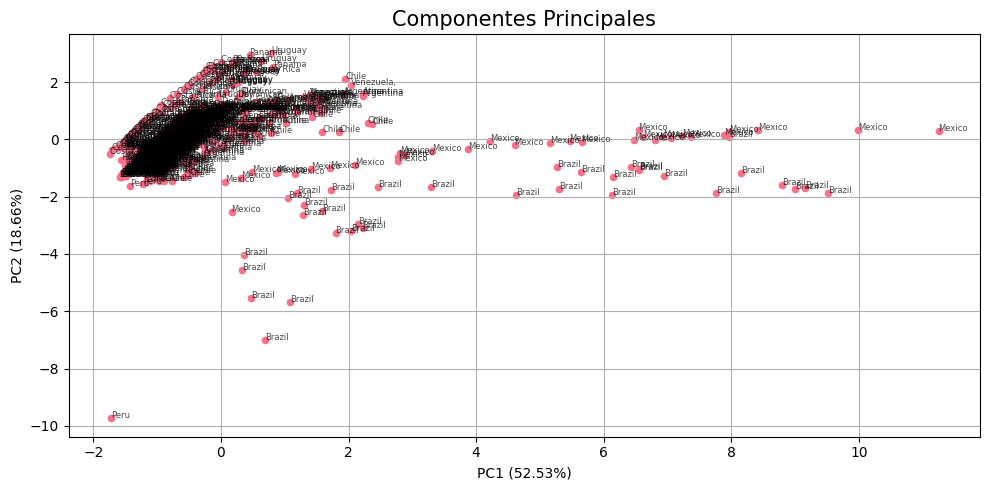

In [99]:
import matplotlib.pyplot as plt

# Crear figura y ejes
fig, ax = plt.subplots(figsize=(10, 5))

# Etiquetas de los ejes con varianza explicada
x_label = 'PC1 (' + str(round(pca.explained_variance_ratio_[0]*100, 2)) + '%)'
y_label = 'PC2 (' + str(round(pca.explained_variance_ratio_[1]*100, 2)) + '%)'

# Scatter plot
ax.scatter(df_pca['PC1'], df_pca['PC2'], s=20)

# Agregar nombres de países como texto (opcional)
for i, name in enumerate(df_pca['Country']):
    ax.text(df_pca['PC1'][i], df_pca['PC2'][i], name[:10], fontsize=6, alpha=0.7)

# Configuración
ax.set_title('Componentes Principales', fontsize=15)
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.grid(True)


plt.tight_layout()
plt.show()


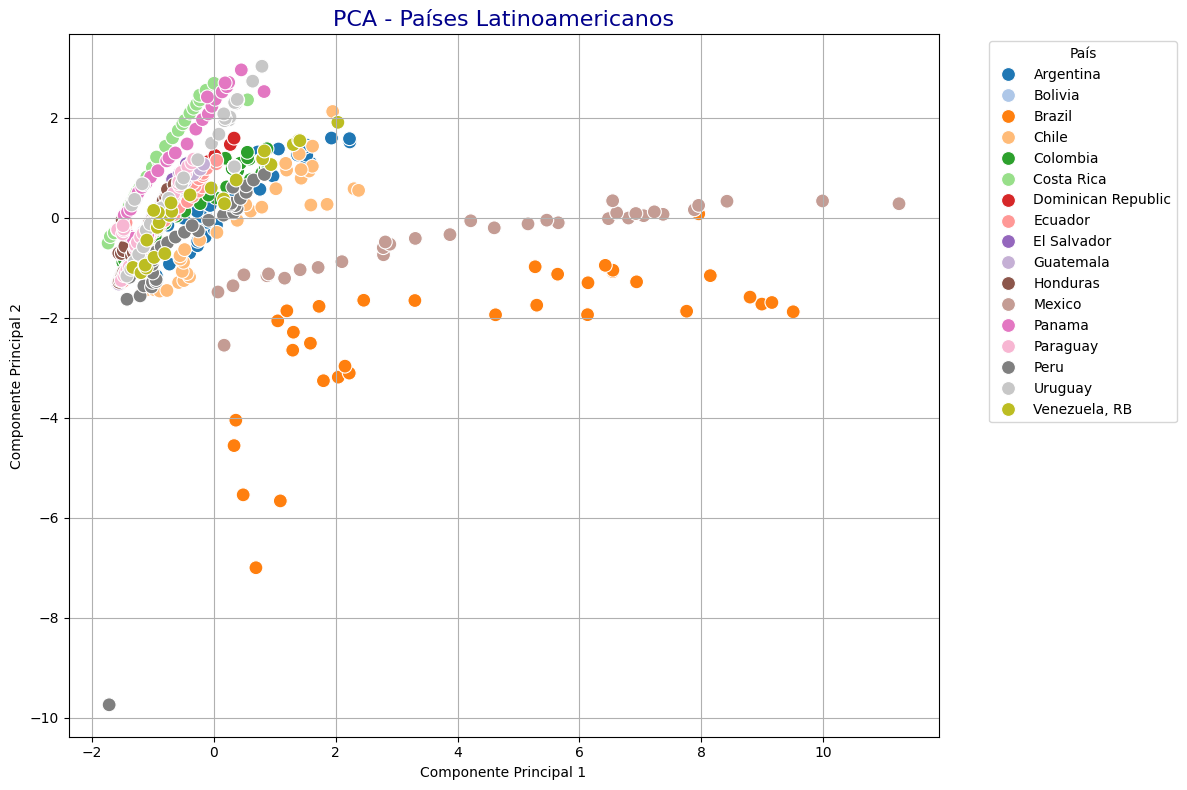

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Country', palette='tab20', s=100)

# Mostrar nombres de países junto a los puntos (opcional)
#for i in range(df_pca.shape[0]):
   # plt.text(x=df_pca.PC1[i]+0.1, y=df_pca.PC2[i]+0.1, s=df_pca.Country[i], fontsize=9)

plt.title('PCA - Países Latinoamericanos', fontsize=16, color='darkblue')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='País')
plt.grid(True)
plt.tight_layout()
plt.show()


### Correlaciones Macroeconómicas

In [124]:
corr_spearman= macro_var_numericas_latam.corr('spearman')
corr_spearman

,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies
GDP,1.000000,0.714087,0.954171,0.951754,0.986648,-0.202808,0.558387
GDP per capita,0.714087,1.000000,0.773498,0.761466,0.733786,-0.350708,-0.033845
Exports,0.954171,0.773498,1.000000,0.978050,0.967136,-0.281876,0.473902
Imports,0.951754,0.761466,0.978050,1.000000,0.969490,-0.299294,0.479250
Gross capital formation,0.986648,0.733786,0.967136,0.969490,1.000000,-0.211483,0.554909
Inflation,-0.202808,-0.350708,-0.281876,-0.299294,-0.211483,1.000000,0.037227
Listed domestic companies,0.558387,-0.033845,0.473902,0.479250,0.554909,0.037227,1.000000


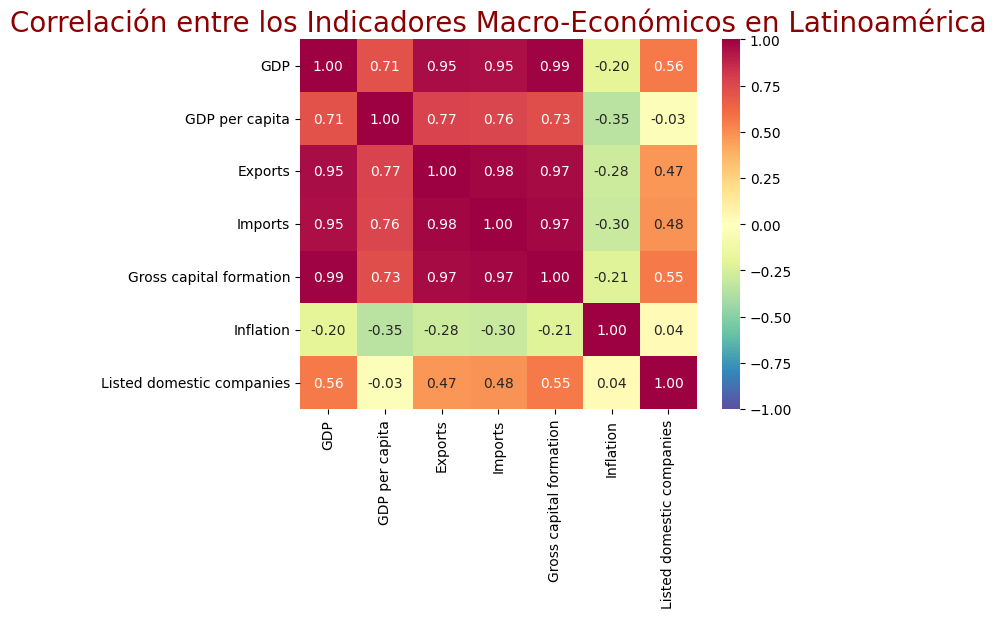

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.color_palette("crest", as_cmap=True)
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="Spectral_r", vmin=-1, vmax=1)
plt.title('Correlación entre los Indicadores Macro-Económicos en Latinoamérica', color='darkred', size=20)
plt.xlabel('')
plt.ylabel('')
plt.show()

In [40]:
# Calcular correlaciones
correlaciones_macro_latam = macro_var_numericas_latam.corr()
correlaciones_macro_latam

,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies
GDP,1.000000,0.379989,0.863227,0.865388,0.985630,0.003164,0.471059
GDP per capita,0.379989,1.000000,0.405819,0.399983,0.403013,-0.073015,-0.043782
Exports,0.863227,0.405819,1.000000,0.994772,0.894366,-0.023942,0.251199
Imports,0.865388,0.399983,0.994772,1.000000,0.902031,-0.027396,0.247727
Gross capital formation,0.985630,0.403013,0.894366,0.902031,1.000000,0.002274,0.435248
Inflation,0.003164,-0.073015,-0.023942,-0.027396,0.002274,1.000000,0.363452
Listed domestic companies,0.471059,-0.043782,0.251199,0.247727,0.435248,0.363452,1.000000


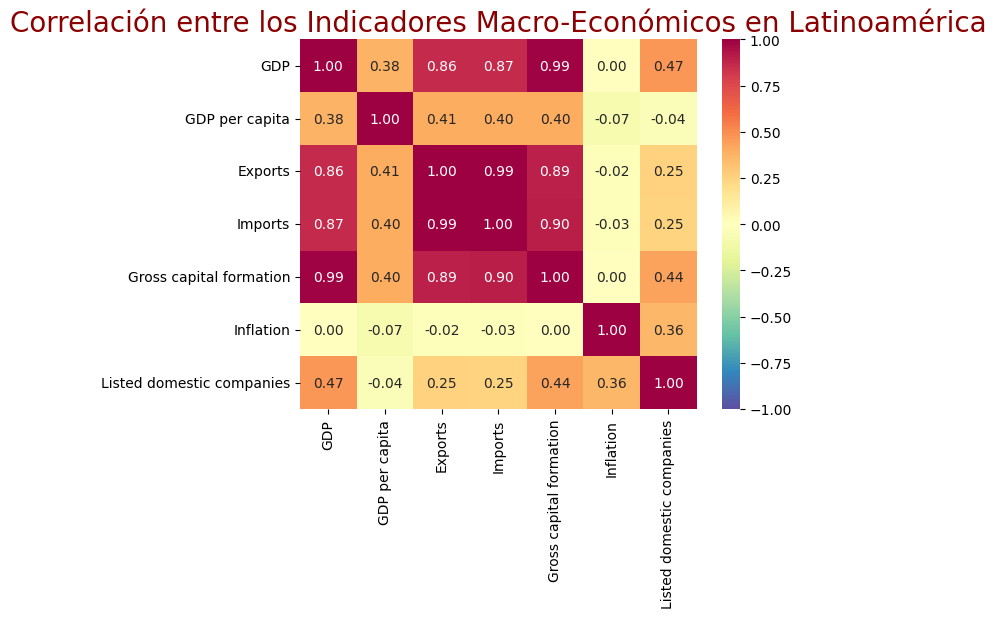

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.color_palette("crest", as_cmap=True)
sns.heatmap(correlaciones_macro_latam, annot=True, fmt=".2f", cmap="Spectral_r", vmin=-1, vmax=1)
plt.title('Correlación entre los Indicadores Macro-Económicos en Latinoamérica', color='darkred', size=20)
plt.xlabel('')
plt.ylabel('')
plt.show()

## Dim_financiera

In [42]:
import pandas as pd

dim_financiera= pd.read_csv(r'C:\Users\lulaz\Desktop\IT Academy - Data Analysis\Proyecto Especialización\Indicadores\2. Indicadores Financieros y Deuda Externa\dim_financiera_v1.csv'
                            , decimal=',')
dim_financiera 

,Country,Year,"Debt service on external debt, total (TDS, current US$)","External debt stocks, total (DOD, current US$)","Foreign direct investment, net inflows (BoP, current US$)","Stocks traded, total value (current US$)","Total reserves (includes gold, current US$)","Use of IMF credit (DOD, current US$)"
0,Afghanistan,1960,NaN,NaN,NaN,NaN,5.069080e+07,NaN
1,Afghanistan,1961,NaN,NaN,NaN,NaN,4.244450e+07,NaN
2,Afghanistan,1962,NaN,NaN,NaN,NaN,4.059210e+07,NaN
3,Afghanistan,1963,NaN,NaN,NaN,NaN,4.554780e+07,NaN
4,Afghanistan,1964,NaN,NaN,NaN,NaN,4.461968e+07,NaN
...,...,...,...,...,...,...,...,...
13348,Zimbabwe,2020,9.846859e+08,1.274203e+10,1.503600e+08,NaN,3.340502e+07,4.876475e+08
13349,Zimbabwe,2021,6.074121e+08,1.381758e+10,2.374804e+08,NaN,8.387802e+08,1.422011e+09
13350,Zimbabwe,2022,4.542304e+08,1.382954e+10,3.367610e+08,NaN,5.986216e+08,1.352160e+09
13351,Zimbabwe,2023,1.161955e+09,1.421339e+10,5.578730e+08,NaN,1.155297e+08,1.363159e+09


In [43]:
columnasfin = dim_financiera.columns.tolist()
print(columnasfin)

['Country', 'Year', 'Debt service on external debt, total (TDS, current US$)', 'External debt stocks, total (DOD, current US$)', 'Foreign direct investment, net inflows (BoP, current US$)', 'Stocks traded, total value (current US$)', 'Total reserves (includes gold, current US$)', 'Use of IMF credit (DOD, current US$)']


In [44]:
dim_financiera.columns=['Country', 'Year', 'Debt service', 'External debt stocks', 'Foreign direct investment', 'Stocks traded', 'Total reserves', 'Use of IMF credit']

In [45]:
Latam_financiera=dim_financiera[dim_financiera['Country'].isin(['Argentina', 'Bolivia', 'Brazil','Chile','Colombia', 'Costa Rica','Dominican Republic','Ecuador', 'El Salvador','Guatemala', 'Honduras', 'Mexico', 'Panama','Paraguay', 'Peru','Uruguay', 
                    'Venezuela, RB'  ])]

Latam_financiera

,Country,Year,Debt service,External debt stocks,Foreign direct investment,Stocks traded,Total reserves,Use of IMF credit
438,Argentina,1960,NaN,NaN,NaN,NaN,527233600.0,NaN
439,Argentina,1961,NaN,NaN,NaN,NaN,386407550.0,NaN
440,Argentina,1962,NaN,NaN,NaN,NaN,114741240.0,NaN
441,Argentina,1963,NaN,NaN,NaN,NaN,269807440.0,NaN
442,Argentina,1964,NaN,NaN,NaN,NaN,153293600.0,NaN
...,...,...,...,...,...,...,...,...
13039,"Venezuela, RB",2019,NaN,NaN,-1.367000e+09,NaN,NaN,NaN
13040,"Venezuela, RB",2020,NaN,NaN,1.504000e+09,NaN,NaN,NaN
13041,"Venezuela, RB",2021,NaN,NaN,9.640000e+08,NaN,NaN,NaN
13042,"Venezuela, RB",2022,NaN,NaN,1.651000e+09,NaN,NaN,NaN


In [46]:
#Latam_financiera["Year"] = Latam_financiera['Year','Debt service on external debt, total (TDS, current US$)', 'External debt stocks, total (DOD, current US$)', 'Foreign direct investment, net inflows (BoP, current US$)', 'Stocks traded, total value (current US$)', 'Total reserves (includes gold, current US$)', 'Use of IMF credit (DOD, current US$)'].astype(int)
Latam_financiera.loc[:, "Year"] = Latam_financiera["Year"].astype(int)
Latam_financiera=Latam_financiera[Latam_financiera["Year"] >= 1990]
Latam_financiera

,Country,Year,Debt service,External debt stocks,Foreign direct investment,Stocks traded,Total reserves,Use of IMF credit
468,Argentina,1990,6.184791e+09,6.247760e+10,1.836000e+09,8.007700e+08,6.222040e+09,3.083196e+09
469,Argentina,1991,5.449279e+09,6.567237e+10,2.439000e+09,4.548690e+09,7.462544e+09,2.483115e+09
470,Argentina,1992,4.914055e+09,6.860564e+10,4.430978e+09,1.573861e+10,1.144703e+10,2.313851e+09
471,Argentina,1993,5.872302e+09,6.468139e+10,2.793085e+09,4.976453e+10,1.549943e+10,3.519668e+09
472,Argentina,1994,5.783539e+09,7.509406e+10,3.634932e+09,1.128280e+11,1.600327e+10,4.211220e+09
...,...,...,...,...,...,...,...,...
13039,"Venezuela, RB",2019,NaN,NaN,-1.367000e+09,NaN,NaN,NaN
13040,"Venezuela, RB",2020,NaN,NaN,1.504000e+09,NaN,NaN,NaN
13041,"Venezuela, RB",2021,NaN,NaN,9.640000e+08,NaN,NaN,NaN
13042,"Venezuela, RB",2022,NaN,NaN,1.651000e+09,NaN,NaN,NaN


In [47]:
columnas_fin = Latam_financiera.columns.tolist()
print(columnas_fin)

['Country', 'Year', 'Debt service', 'External debt stocks', 'Foreign direct investment', 'Stocks traded', 'Total reserves', 'Use of IMF credit']


In [48]:
finan=['Debt service', 'External debt stocks', 'Foreign direct investment', 'Stocks traded', 'Total reserves', 'Use of IMF credit']
financieras_var_numericas_latam = Latam_financiera[finan]
financieras_var_numericas_latam = financieras_var_numericas_latam.astype(float)

financieras_var_numericas_latam



,Debt service,External debt stocks,Foreign direct investment,Stocks traded,Total reserves,Use of IMF credit
468,6.184791e+09,6.247760e+10,1.836000e+09,8.007700e+08,6.222040e+09,3.083196e+09
469,5.449279e+09,6.567237e+10,2.439000e+09,4.548690e+09,7.462544e+09,2.483115e+09
470,4.914055e+09,6.860564e+10,4.430978e+09,1.573861e+10,1.144703e+10,2.313851e+09
471,5.872302e+09,6.468139e+10,2.793085e+09,4.976453e+10,1.549943e+10,3.519668e+09
472,5.783539e+09,7.509406e+10,3.634932e+09,1.128280e+11,1.600327e+10,4.211220e+09
...,...,...,...,...,...,...
13039,NaN,NaN,-1.367000e+09,NaN,NaN,NaN
13040,NaN,NaN,1.504000e+09,NaN,NaN,NaN
13041,NaN,NaN,9.640000e+08,NaN,NaN,NaN
13042,NaN,NaN,1.651000e+09,NaN,NaN,NaN


### Correlaciones Financieras

In [49]:
correlaciones_Latam_financiera = financieras_var_numericas_latam.corr()
correlaciones_Latam_financiera

,Debt service,External debt stocks,Foreign direct investment,Stocks traded,Total reserves,Use of IMF credit
Debt service,1.000000,0.893497,0.823125,0.781119,0.857659,0.420855
External debt stocks,0.893497,1.000000,0.856940,0.642600,0.888202,0.459340
Foreign direct investment,0.823125,0.856940,1.000000,0.797981,0.930525,0.256407
Stocks traded,0.781119,0.642600,0.797981,1.000000,0.860988,0.105646
Total reserves,0.857659,0.888202,0.930525,0.860988,1.000000,0.248087
Use of IMF credit,0.420855,0.459340,0.256407,0.105646,0.248087,1.000000


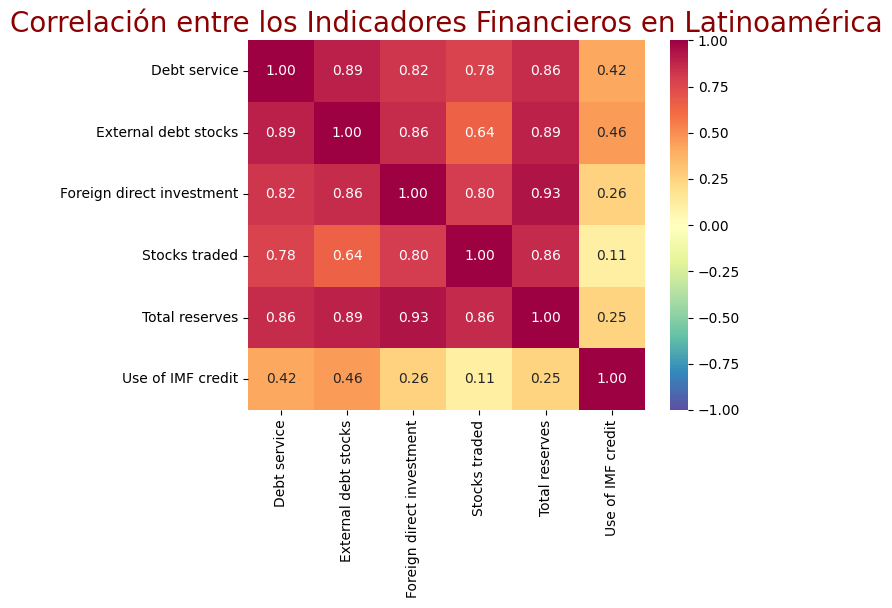

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.heatmap(correlaciones_Latam_financiera, annot=True, fmt=".2f", cmap="Spectral_r", vmin=-1, vmax=1)
plt.title('Correlación entre los Indicadores Financieros en Latinoamérica', color='darkred', size=20)
plt.xlabel('')
plt.ylabel('')
plt.show()

In [51]:
print(Latam_macro.columns)
print(Latam_financiera.columns)

Index(['Country', 'Year', 'GDP', 'GDP per capita', 'Exports', 'Imports',
       'Gross capital formation', 'Inflation', 'Listed domestic companies'],
      dtype='object')
Index(['Country', 'Year', 'Debt service', 'External debt stocks',
       'Foreign direct investment', 'Stocks traded', 'Total reserves',
       'Use of IMF credit'],
      dtype='object')


In [52]:
macro_financ= pd.merge(Latam_macro, Latam_financiera, on=["Country", "Year"], how="outer")
macro_financ
print(macro_financ.columns)



Index(['Country', 'Year', 'GDP', 'GDP per capita', 'Exports', 'Imports',
       'Gross capital formation', 'Inflation', 'Listed domestic companies',
       'Debt service', 'External debt stocks', 'Foreign direct investment',
       'Stocks traded', 'Total reserves', 'Use of IMF credit'],
      dtype='object')


In [53]:
cols_macro_financ_numericas = [
    'GDP', 'GDP per capita', 'Exports', 'Imports',
    'Gross capital formation', 'Inflation', 'Listed domestic companies',
    'Debt service', 'External debt stocks', 'Foreign direct investment',
    'Stocks traded', 'Total reserves', 'Use of IMF credit'
]

macro_financ_numericas = macro_financ[cols_macro_financ_numericas]

macro_financ_numericas

,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,External debt stocks,Foreign direct investment,Stocks traded,Total reserves,Use of IMF credit
0,1.413526e+11,4315.333294,1.464348e+10,6.546496e+09,1.978510e+10,NaN,178.0,6.184791e+09,6.247760e+10,1.836000e+09,8.007700e+08,6.222040e+09,3.083196e+09
1,1.897200e+11,5709.247841,1.456109e+10,1.153120e+10,2.776927e+10,NaN,169.0,5.449279e+09,6.567237e+10,2.439000e+09,4.548690e+09,7.462544e+09,2.483115e+09
2,2.287789e+11,6789.996111,1.509526e+10,1.860612e+10,3.821158e+10,NaN,170.0,4.914055e+09,6.860564e+10,4.430978e+09,1.573861e+10,1.144703e+10,2.313851e+09
3,2.367417e+11,6931.855964,1.635732e+10,2.204965e+10,4.660997e+10,NaN,165.0,5.872302e+09,6.468139e+10,2.793085e+09,4.976453e+10,1.549943e+10,3.519668e+09
4,2.574400e+11,7437.562423,1.938510e+10,2.729996e+10,5.139950e+10,NaN,156.0,5.783539e+09,7.509406e+10,3.634932e+09,1.128280e+11,1.600327e+10,4.211220e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.367000e+09,NaN,NaN,NaN
590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.504000e+09,NaN,NaN,NaN
591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.640000e+08,NaN,NaN,NaN
592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.651000e+09,NaN,NaN,NaN


In [54]:
correlaciones_macro_financ=macro_financ_numericas.corr()
correlaciones_macro_financ

,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,External debt stocks,Foreign direct investment,Stocks traded,Total reserves,Use of IMF credit
GDP,1.000000,0.379989,0.863227,0.865388,0.985630,0.003164,0.471059,0.865526,0.920276,0.939368,0.791545,0.940103,0.315960
GDP per capita,0.379989,1.000000,0.405819,0.399983,0.403013,-0.073015,-0.043782,0.498135,0.616371,0.383532,0.207416,0.339637,0.359603
Exports,0.863227,0.405819,1.000000,0.994772,0.894366,-0.023942,0.251199,0.776134,0.922404,0.773480,0.520920,0.808946,0.299081
Imports,0.865388,0.399983,0.994772,1.000000,0.902031,-0.027396,0.247727,0.757557,0.916726,0.778487,0.514390,0.804733,0.279510
Gross capital formation,0.985630,0.403013,0.894366,0.902031,1.000000,0.002274,0.435248,0.810930,0.905874,0.919083,0.735202,0.905911,0.288187
Inflation,0.003164,-0.073015,-0.023942,-0.027396,0.002274,1.000000,0.363452,-0.024125,0.001231,-0.037246,-0.029969,-0.022879,-0.017141
Listed domestic companies,0.471059,-0.043782,0.251199,0.247727,0.435248,0.363452,1.000000,0.476853,0.406091,0.442744,0.428111,0.407672,0.106683
Debt service,0.865526,0.498135,0.776134,0.757557,0.810930,-0.024125,0.476853,1.000000,0.893497,0.823125,0.781119,0.857659,0.420855
External debt stocks,0.920276,0.616371,0.922404,0.916726,0.905874,0.001231,0.406091,0.893497,1.000000,0.856940,0.642600,0.888202,0.459340
Foreign direct investment,0.939368,0.383532,0.773480,0.778487,0.919083,-0.037246,0.442744,0.823125,0.856940,1.000000,0.797981,0.930525,0.256407


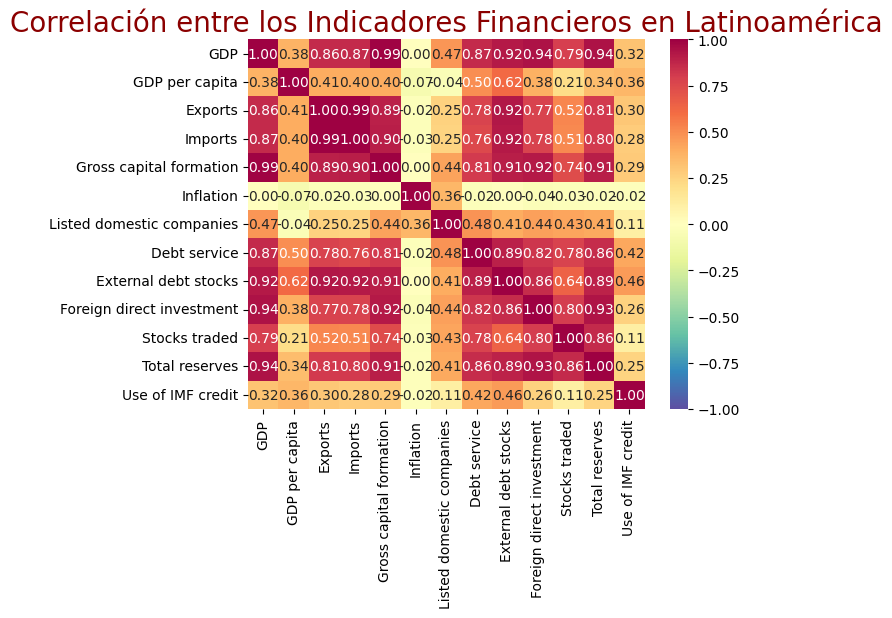

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.heatmap(correlaciones_macro_financ, annot=True, fmt=".2f", cmap="Spectral_r", vmin=-1, vmax=1)
plt.title('Correlación entre los Indicadores Financieros en Latinoamérica', color='darkred', size=20)
plt.xlabel('', )
plt.ylabel('')
plt.show()

In [56]:
macro_financ.head()

,Country,Year,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,External debt stocks,Foreign direct investment,Stocks traded,Total reserves,Use of IMF credit
0,Argentina,1990,1.413526e+11,4315.333294,1.464348e+10,6.546496e+09,1.978510e+10,NaN,178.0,6.184791e+09,6.247760e+10,1.836000e+09,8.007700e+08,6.222040e+09,3.083196e+09
1,Argentina,1991,1.897200e+11,5709.247841,1.456109e+10,1.153120e+10,2.776927e+10,NaN,169.0,5.449279e+09,6.567237e+10,2.439000e+09,4.548690e+09,7.462544e+09,2.483115e+09
2,Argentina,1992,2.287789e+11,6789.996111,1.509526e+10,1.860612e+10,3.821158e+10,NaN,170.0,4.914055e+09,6.860564e+10,4.430978e+09,1.573861e+10,1.144703e+10,2.313851e+09
3,Argentina,1993,2.367417e+11,6931.855964,1.635732e+10,2.204965e+10,4.660997e+10,NaN,165.0,5.872302e+09,6.468139e+10,2.793085e+09,4.976453e+10,1.549943e+10,3.519668e+09
4,Argentina,1994,2.574400e+11,7437.562423,1.938510e+10,2.729996e+10,5.139950e+10,NaN,156.0,5.783539e+09,7.509406e+10,3.634932e+09,1.128280e+11,1.600327e+10,4.211220e+09


## Hacemos entrar a la dimensión Productivo-Extractiva(cambiamos a valores netos)

In [57]:
import pandas as pd

dim_productivo_extractiva= pd.read_csv(r"C:\Users\lulaz\Desktop\IT Academy - Data Analysis\Proyecto Especialización\Indicadores\3. Indicadores Productivos-extractivos\dim_productivoextractiva_val_netos.csv"
                            , decimal=',')
dim_productivo_extractiva 

,Country,Year,High-technology exports (current US$),"International tourism, receipts (current US$)","Manufacturing, value added (current US$)","Agriculture, forestry, and fishing, value added (Current US$)",Coal rents (Current US$),Forest rents (Current US$),Fuel exports (Current US$),Mineral rents (Current US$),Natural gas rents (Current US$),Oil rents (Current US$),Ores and metals exports (Current US$),Total natural resources rents (Current US$)
0,Afghanistan,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14845,Zimbabwe,2019,27782789.0,285000000.0,3.657623e+09,2.525260e+09,6.628791e+07,5.133329e+08,7.979765e+07,6.200663e+08,0.0,1.308567e+07,2.492043e+09,1.212773e+09
14846,Zimbabwe,2020,8275259.0,66000000.0,4.217343e+09,2.357086e+09,5.573196e+07,6.084010e+08,6.606247e+07,6.033724e+08,0.0,7.826441e+06,2.680912e+09,1.275332e+09
14847,Zimbabwe,2021,4788223.0,NaN,3.389519e+09,2.410758e+09,7.903314e+07,4.957481e+08,9.716547e+07,1.155178e+09,0.0,1.301247e+07,2.855750e+09,1.742971e+09
14848,Zimbabwe,2022,7822102.0,NaN,6.732872e+09,2.351205e+09,NaN,NaN,2.645117e+08,NaN,NaN,NaN,3.672581e+09,NaN


In [58]:
columnasfin = dim_productivo_extractiva.columns.tolist()
print(columnasfin)

['Country', 'Year', 'High-technology exports (current US$)', 'International tourism, receipts (current US$)', 'Manufacturing, value added (current US$)', 'Agriculture, forestry, and fishing, value added (Current US$)', 'Coal rents (Current US$)', 'Forest rents (Current US$)', 'Fuel exports (Current US$)', 'Mineral rents (Current US$)', 'Natural gas rents (Current US$)', 'Oil rents (Current US$)', 'Ores and metals exports (Current US$)', 'Total natural resources rents (Current US$)']


In [59]:
Latam_productivo_extractivo=dim_productivo_extractiva[dim_productivo_extractiva['Country'].isin(['Argentina', 'Bolivia', 'Brazil','Chile','Colombia', 'Costa Rica','Dominican Republic','Ecuador', 'El Salvador','Guatemala', 'Honduras', 'Mexico', 'Panama','Paraguay', 'Peru','Uruguay', 
                    'Venezuela, RB'  ])]

Latam_productivo_extractivo

,Country,Year,High-technology exports (current US$),"International tourism, receipts (current US$)","Manufacturing, value added (current US$)","Agriculture, forestry, and fishing, value added (Current US$)",Coal rents (Current US$),Forest rents (Current US$),Fuel exports (Current US$),Mineral rents (Current US$),Natural gas rents (Current US$),Oil rents (Current US$),Ores and metals exports (Current US$),Total natural resources rents (Current US$)
527,Argentina,1962,NaN,NaN,NaN,NaN,NaN,NaN,1.239930e+07,NaN,NaN,NaN,9.330454e+06,NaN
528,Argentina,1963,NaN,NaN,NaN,NaN,NaN,NaN,1.186008e+07,NaN,NaN,NaN,1.202161e+07,NaN
529,Argentina,1964,NaN,NaN,NaN,NaN,NaN,NaN,6.158116e+06,NaN,NaN,NaN,7.127347e+06,NaN
530,Argentina,1965,NaN,NaN,1.167353e+10,3.657647e+09,NaN,NaN,1.086298e+07,NaN,NaN,NaN,4.746820e+06,NaN
531,Argentina,1966,NaN,NaN,1.174095e+10,2.942857e+09,NaN,NaN,1.673566e+07,NaN,NaN,NaN,5.459885e+06,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14514,"Venezuela, RB",2012,NaN,904000000.0,4.486826e+10,1.912672e+10,5.368010e+07,1.784063e+08,9.855285e+10,1.067429e+09,1.912644e+09,6.839811e+10,4.591994e+07,7.161027e+10
14515,"Venezuela, RB",2013,NaN,926000000.0,4.271868e+10,1.818872e+10,3.303027e+07,2.281619e+08,8.974578e+10,8.738981e+08,2.011800e+09,6.224409e+10,4.059047e+08,6.539098e+10
14516,"Venezuela, RB",2014,NaN,900000000.0,5.823696e+10,2.424701e+10,3.292382e+07,2.627733e+08,NaN,5.079015e+08,1.822159e+09,5.451698e+10,NaN,5.714274e+10
14517,"Venezuela, RB",2015,NaN,654000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
Latam_productivo_extractivo.loc[:, "Year"] = Latam_productivo_extractivo["Year"].astype(int)
Latam_productivo_extractivo=Latam_productivo_extractivo[Latam_productivo_extractivo["Year"] >= 1990]
Latam_productivo_extractivo

,Country,Year,High-technology exports (current US$),"International tourism, receipts (current US$)","Manufacturing, value added (current US$)","Agriculture, forestry, and fishing, value added (Current US$)",Coal rents (Current US$),Forest rents (Current US$),Fuel exports (Current US$),Mineral rents (Current US$),Natural gas rents (Current US$),Oil rents (Current US$),Ores and metals exports (Current US$),Total natural resources rents (Current US$)
555,Argentina,1990,NaN,NaN,3.786795e+10,1.148303e+10,1.434646e+06,1.999938e+08,NaN,8.496686e+07,2.205132e+08,3.085334e+09,NaN,3.592242e+09
556,Argentina,1991,NaN,NaN,4.626597e+10,1.274253e+10,1.405841e+06,1.884871e+08,NaN,2.441225e+07,1.996186e+08,1.696084e+09,NaN,2.110008e+09
557,Argentina,1992,NaN,NaN,5.000908e+10,1.370566e+10,5.228051e+05,2.236936e+08,1.334316e+09,1.889680e+07,1.810371e+08,2.085297e+09,1.763277e+08,2.509448e+09
558,Argentina,1993,NaN,NaN,4.318148e+10,1.216101e+10,0.000000e+00,2.116768e+08,1.540199e+09,6.731470e+06,2.395626e+08,2.135157e+09,1.895814e+08,2.593128e+09
559,Argentina,1994,NaN,NaN,4.587347e+10,1.308482e+10,0.000000e+00,1.730867e+08,2.020156e+09,1.254748e+07,2.144430e+08,2.271162e+09,2.543149e+08,2.671239e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14514,"Venezuela, RB",2012,NaN,904000000.0,4.486826e+10,1.912672e+10,5.368010e+07,1.784063e+08,9.855285e+10,1.067429e+09,1.912644e+09,6.839811e+10,4.591994e+07,7.161027e+10
14515,"Venezuela, RB",2013,NaN,926000000.0,4.271868e+10,1.818872e+10,3.303027e+07,2.281619e+08,8.974578e+10,8.738981e+08,2.011800e+09,6.224409e+10,4.059047e+08,6.539098e+10
14516,"Venezuela, RB",2014,NaN,900000000.0,5.823696e+10,2.424701e+10,3.292382e+07,2.627733e+08,NaN,5.079015e+08,1.822159e+09,5.451698e+10,NaN,5.714274e+10
14517,"Venezuela, RB",2015,NaN,654000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
print(Latam_productivo_extractivo.columns)

Index(['Country', 'Year', 'High-technology exports (current US$)',
       'International tourism, receipts (current US$)',
       'Manufacturing, value added (current US$)',
       'Agriculture, forestry, and fishing, value added (Current US$)',
       'Coal rents (Current US$)', 'Forest rents (Current US$)',
       'Fuel exports (Current US$)', 'Mineral rents (Current US$)',
       'Natural gas rents (Current US$)', 'Oil rents (Current US$)',
       'Ores and metals exports (Current US$)',
       'Total natural resources rents (Current US$)'],
      dtype='object')


In [62]:
proextract = ['High-technology exports (current US$)',
       'International tourism, receipts (current US$)',
       'Manufacturing, value added (current US$)',
       'Agriculture, forestry, and fishing, value added (Current US$)',
       'Coal rents (Current US$)', 'Forest rents (Current US$)',
       'Fuel exports (Current US$)', 'Mineral rents (Current US$)',
       'Natural gas rents (Current US$)', 'Oil rents (Current US$)',
       'Ores and metals exports (Current US$)',
       'Total natural resources rents (Current US$)']

proextract_var_numericas_latam = Latam_productivo_extractivo[proextract]
proextract_var_numericas_latam = proextract_var_numericas_latam.astype(float)

proextract_var_numericas_latam


,High-technology exports (current US$),"International tourism, receipts (current US$)","Manufacturing, value added (current US$)","Agriculture, forestry, and fishing, value added (Current US$)",Coal rents (Current US$),Forest rents (Current US$),Fuel exports (Current US$),Mineral rents (Current US$),Natural gas rents (Current US$),Oil rents (Current US$),Ores and metals exports (Current US$),Total natural resources rents (Current US$)
555,NaN,NaN,3.786795e+10,1.148303e+10,1.434646e+06,1.999938e+08,NaN,8.496686e+07,2.205132e+08,3.085334e+09,NaN,3.592242e+09
556,NaN,NaN,4.626597e+10,1.274253e+10,1.405841e+06,1.884871e+08,NaN,2.441225e+07,1.996186e+08,1.696084e+09,NaN,2.110008e+09
557,NaN,NaN,5.000908e+10,1.370566e+10,5.228051e+05,2.236936e+08,1.334316e+09,1.889680e+07,1.810371e+08,2.085297e+09,1.763277e+08,2.509448e+09
558,NaN,NaN,4.318148e+10,1.216101e+10,0.000000e+00,2.116768e+08,1.540199e+09,6.731470e+06,2.395626e+08,2.135157e+09,1.895814e+08,2.593128e+09
559,NaN,NaN,4.587347e+10,1.308482e+10,0.000000e+00,1.730867e+08,2.020156e+09,1.254748e+07,2.144430e+08,2.271162e+09,2.543149e+08,2.671239e+09
...,...,...,...,...,...,...,...,...,...,...,...,...
14514,NaN,904000000.0,4.486826e+10,1.912672e+10,5.368010e+07,1.784063e+08,9.855285e+10,1.067429e+09,1.912644e+09,6.839811e+10,4.591994e+07,7.161027e+10
14515,NaN,926000000.0,4.271868e+10,1.818872e+10,3.303027e+07,2.281619e+08,8.974578e+10,8.738981e+08,2.011800e+09,6.224409e+10,4.059047e+08,6.539098e+10
14516,NaN,900000000.0,5.823696e+10,2.424701e+10,3.292382e+07,2.627733e+08,NaN,5.079015e+08,1.822159e+09,5.451698e+10,NaN,5.714274e+10
14517,NaN,654000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
correlaciones_latam_prodextr=proextract_var_numericas_latam.corr()
correlaciones_latam_prodextr

,High-technology exports (current US$),"International tourism, receipts (current US$)","Manufacturing, value added (current US$)","Agriculture, forestry, and fishing, value added (Current US$)",Coal rents (Current US$),Forest rents (Current US$),Fuel exports (Current US$),Mineral rents (Current US$),Natural gas rents (Current US$),Oil rents (Current US$),Ores and metals exports (Current US$),Total natural resources rents (Current US$)
High-technology exports (current US$),1.000000,0.869713,0.760590,0.404138,0.078191,0.162232,0.577229,0.156025,0.528396,0.626744,0.119803,0.486308
"International tourism, receipts (current US$)",0.869713,1.000000,0.778911,0.530670,0.199616,0.255218,0.404952,0.266192,0.562475,0.499971,0.253580,0.513017
"Manufacturing, value added (current US$)",0.760590,0.778911,1.000000,0.892203,0.156952,0.671362,0.563501,0.500141,0.624740,0.707018,0.442881,0.788984
"Agriculture, forestry, and fishing, value added (Current US$)",0.404138,0.530670,0.892203,1.000000,0.169971,0.872244,0.520627,0.622618,0.538885,0.619711,0.551809,0.793765
Coal rents (Current US$),0.078191,0.199616,0.156952,0.169971,1.000000,0.025323,0.385055,0.042612,0.202188,0.258347,-0.011177,0.238341
Forest rents (Current US$),0.162232,0.255218,0.671362,0.872244,0.025323,1.000000,0.249422,0.621905,0.235161,0.387681,0.616278,0.629835
Fuel exports (Current US$),0.577229,0.404952,0.563501,0.520627,0.385055,0.249422,1.000000,0.225156,0.598180,0.907061,0.187241,0.780215
Mineral rents (Current US$),0.156025,0.266192,0.500141,0.622618,0.042612,0.621905,0.225156,1.000000,0.245489,0.332700,0.891350,0.690305
Natural gas rents (Current US$),0.528396,0.562475,0.624740,0.538885,0.202188,0.235161,0.598180,0.245489,1.000000,0.706179,0.200893,0.656632
Oil rents (Current US$),0.626744,0.499971,0.707018,0.619711,0.258347,0.387681,0.907061,0.332700,0.706179,1.000000,0.255644,0.906547


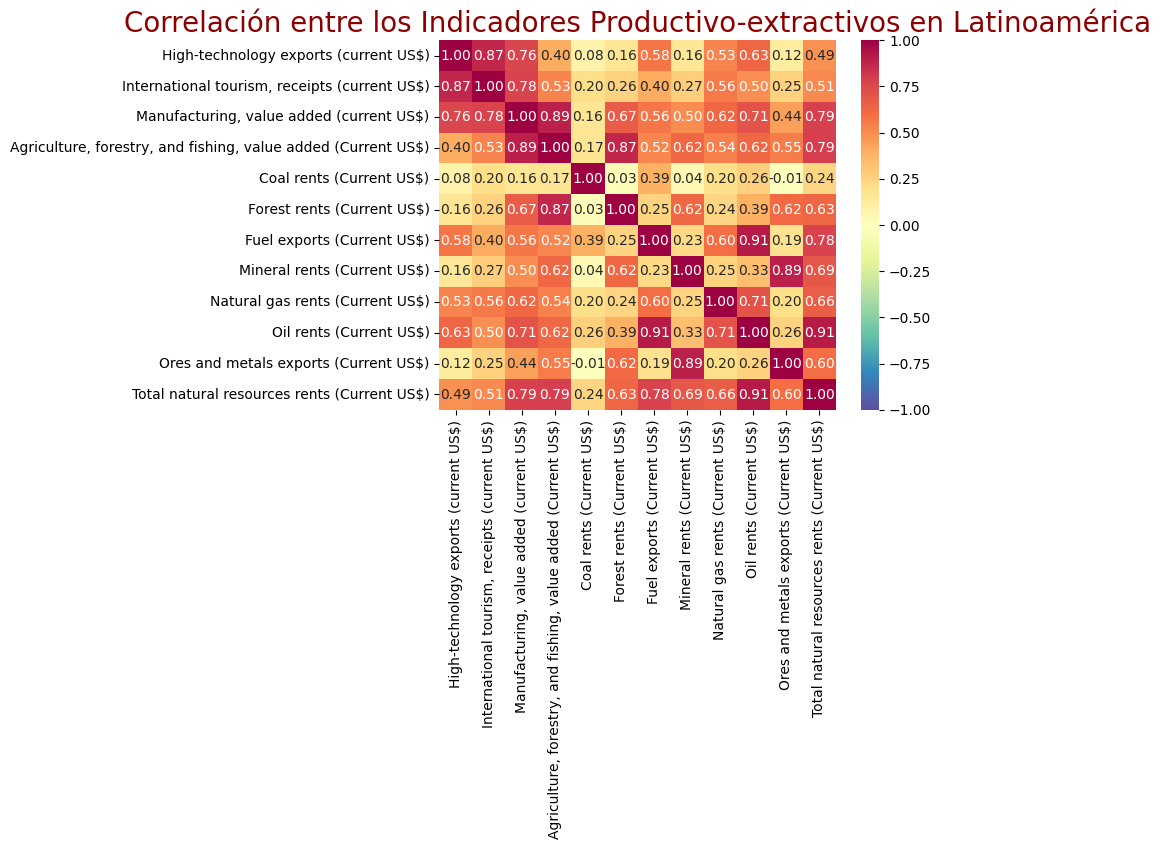

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.heatmap(correlaciones_latam_prodextr, annot=True, fmt=".2f", cmap="Spectral_r", vmin=-1, vmax=1)
plt.title('Correlación entre los Indicadores Productivo-extractivos en Latinoamérica', color='darkred', size=20)
plt.xlabel('')
plt.ylabel('')
plt.show()

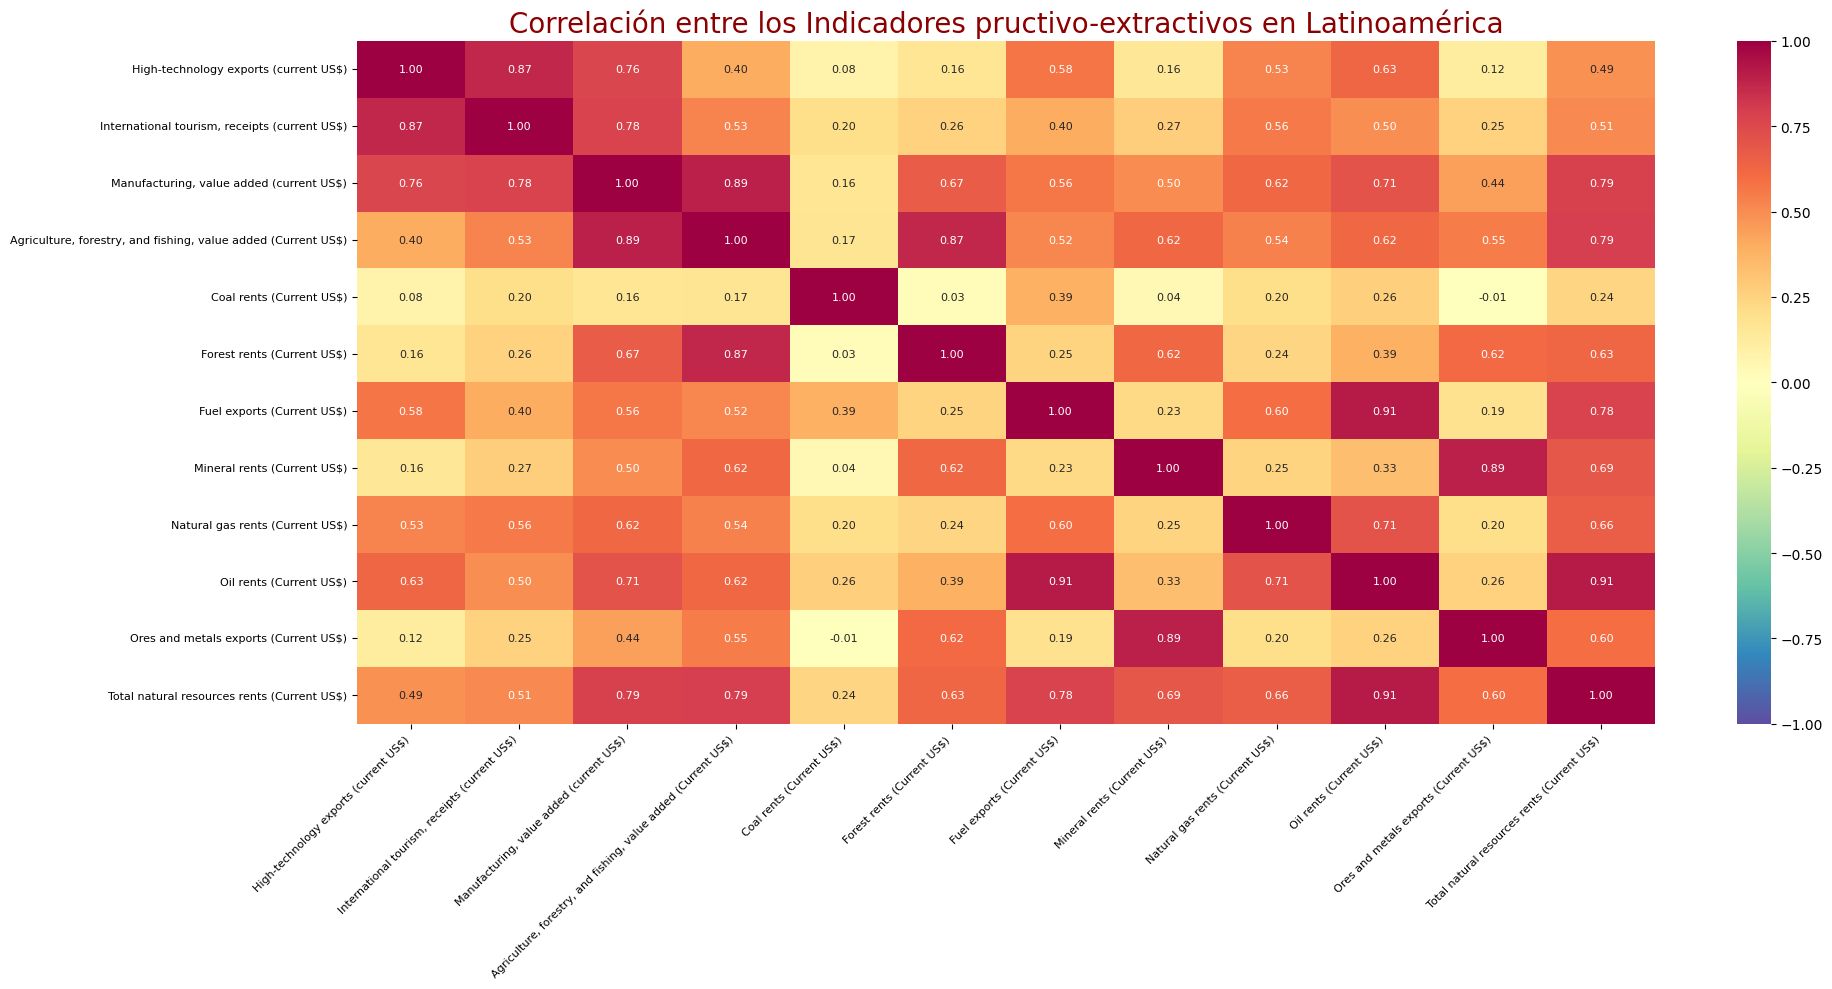

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(20, 10))  # ancho alto
sns.heatmap(
    correlaciones_latam_prodextr,
    annot=True,
    fmt=".2f",
    cmap="Spectral_r",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 8}  # tamaño de letra de los valores anotados
)

plt.title('Correlación entre los Indicadores pructivo-extractivos en Latinoamérica', color='darkred', size=20)
plt.xticks(fontsize=8, rotation=45, ha='right')  # tamaño y orientación etiquetas eje X
plt.yticks(fontsize=8)  # tamaño etiquetas eje Y
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()  # asegura que todo encaje bien
plt.show()

## Incorporamos los indicadores productivos-extractivos al df con los indicadores anteriores

In [66]:
Latam_productivo_extractivo

,Country,Year,High-technology exports (current US$),"International tourism, receipts (current US$)","Manufacturing, value added (current US$)","Agriculture, forestry, and fishing, value added (Current US$)",Coal rents (Current US$),Forest rents (Current US$),Fuel exports (Current US$),Mineral rents (Current US$),Natural gas rents (Current US$),Oil rents (Current US$),Ores and metals exports (Current US$),Total natural resources rents (Current US$)
555,Argentina,1990,NaN,NaN,3.786795e+10,1.148303e+10,1.434646e+06,1.999938e+08,NaN,8.496686e+07,2.205132e+08,3.085334e+09,NaN,3.592242e+09
556,Argentina,1991,NaN,NaN,4.626597e+10,1.274253e+10,1.405841e+06,1.884871e+08,NaN,2.441225e+07,1.996186e+08,1.696084e+09,NaN,2.110008e+09
557,Argentina,1992,NaN,NaN,5.000908e+10,1.370566e+10,5.228051e+05,2.236936e+08,1.334316e+09,1.889680e+07,1.810371e+08,2.085297e+09,1.763277e+08,2.509448e+09
558,Argentina,1993,NaN,NaN,4.318148e+10,1.216101e+10,0.000000e+00,2.116768e+08,1.540199e+09,6.731470e+06,2.395626e+08,2.135157e+09,1.895814e+08,2.593128e+09
559,Argentina,1994,NaN,NaN,4.587347e+10,1.308482e+10,0.000000e+00,1.730867e+08,2.020156e+09,1.254748e+07,2.144430e+08,2.271162e+09,2.543149e+08,2.671239e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14514,"Venezuela, RB",2012,NaN,904000000.0,4.486826e+10,1.912672e+10,5.368010e+07,1.784063e+08,9.855285e+10,1.067429e+09,1.912644e+09,6.839811e+10,4.591994e+07,7.161027e+10
14515,"Venezuela, RB",2013,NaN,926000000.0,4.271868e+10,1.818872e+10,3.303027e+07,2.281619e+08,8.974578e+10,8.738981e+08,2.011800e+09,6.224409e+10,4.059047e+08,6.539098e+10
14516,"Venezuela, RB",2014,NaN,900000000.0,5.823696e+10,2.424701e+10,3.292382e+07,2.627733e+08,NaN,5.079015e+08,1.822159e+09,5.451698e+10,NaN,5.714274e+10
14517,"Venezuela, RB",2015,NaN,654000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
macro_financ

,Country,Year,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,External debt stocks,Foreign direct investment,Stocks traded,Total reserves,Use of IMF credit
0,Argentina,1990,1.413526e+11,4315.333294,1.464348e+10,6.546496e+09,1.978510e+10,NaN,178.0,6.184791e+09,6.247760e+10,1.836000e+09,8.007700e+08,6.222040e+09,3.083196e+09
1,Argentina,1991,1.897200e+11,5709.247841,1.456109e+10,1.153120e+10,2.776927e+10,NaN,169.0,5.449279e+09,6.567237e+10,2.439000e+09,4.548690e+09,7.462544e+09,2.483115e+09
2,Argentina,1992,2.287789e+11,6789.996111,1.509526e+10,1.860612e+10,3.821158e+10,NaN,170.0,4.914055e+09,6.860564e+10,4.430978e+09,1.573861e+10,1.144703e+10,2.313851e+09
3,Argentina,1993,2.367417e+11,6931.855964,1.635732e+10,2.204965e+10,4.660997e+10,NaN,165.0,5.872302e+09,6.468139e+10,2.793085e+09,4.976453e+10,1.549943e+10,3.519668e+09
4,Argentina,1994,2.574400e+11,7437.562423,1.938510e+10,2.729996e+10,5.139950e+10,NaN,156.0,5.783539e+09,7.509406e+10,3.634932e+09,1.128280e+11,1.600327e+10,4.211220e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,"Venezuela, RB",2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.367000e+09,NaN,NaN,NaN
590,"Venezuela, RB",2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.504000e+09,NaN,NaN,NaN
591,"Venezuela, RB",2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.640000e+08,NaN,NaN,NaN
592,"Venezuela, RB",2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.651000e+09,NaN,NaN,NaN


In [68]:
macro_financ_prodextr= pd.merge(macro_financ, Latam_productivo_extractivo, on=["Country", "Year"], how="outer")
print(macro_financ_prodextr.columns)

Index(['Country', 'Year', 'GDP', 'GDP per capita', 'Exports', 'Imports',
       'Gross capital formation', 'Inflation', 'Listed domestic companies',
       'Debt service', 'External debt stocks', 'Foreign direct investment',
       'Stocks traded', 'Total reserves', 'Use of IMF credit',
       'High-technology exports (current US$)',
       'International tourism, receipts (current US$)',
       'Manufacturing, value added (current US$)',
       'Agriculture, forestry, and fishing, value added (Current US$)',
       'Coal rents (Current US$)', 'Forest rents (Current US$)',
       'Fuel exports (Current US$)', 'Mineral rents (Current US$)',
       'Natural gas rents (Current US$)', 'Oil rents (Current US$)',
       'Ores and metals exports (Current US$)',
       'Total natural resources rents (Current US$)'],
      dtype='object')


In [ ]:
macro_financ_prodextr
print(macro_financ_prodextr.columns)

Index(['Country', 'Year', 'GDP', 'GDP per capita', 'Exports', 'Imports',
       'Gross capital formation', 'Inflation', 'Listed domestic companies',
       'Debt service', 'External debt stocks', 'Foreign direct investment',
       'Stocks traded', 'Total reserves', 'Use of IMF credit',
       'High-technology exports (current US$)',
       'International tourism, receipts (current US$)',
       'Manufacturing, value added (current US$)',
       'Agriculture, forestry, and fishing, value added (Current US$)',
       'Coal rents (Current US$)', 'Forest rents (Current US$)',
       'Fuel exports (Current US$)', 'Mineral rents (Current US$)',
       'Natural gas rents (Current US$)', 'Oil rents (Current US$)',
       'Ores and metals exports (Current US$)',
       'Total natural resources rents (Current US$)'],
      dtype='object')


In [69]:
macro_financ_prodextr

,Country,Year,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,...,"Manufacturing, value added (current US$)","Agriculture, forestry, and fishing, value added (Current US$)",Coal rents (Current US$),Forest rents (Current US$),Fuel exports (Current US$),Mineral rents (Current US$),Natural gas rents (Current US$),Oil rents (Current US$),Ores and metals exports (Current US$),Total natural resources rents (Current US$)
0,Argentina,1990,1.413526e+11,4315.333294,1.464348e+10,6.546496e+09,1.978510e+10,NaN,178.0,6.184791e+09,...,3.786795e+10,1.148303e+10,1.434646e+06,1.999938e+08,NaN,8.496686e+07,2.205132e+08,3.085334e+09,NaN,3.592242e+09
1,Argentina,1991,1.897200e+11,5709.247841,1.456109e+10,1.153120e+10,2.776927e+10,NaN,169.0,5.449279e+09,...,4.626597e+10,1.274253e+10,1.405841e+06,1.884871e+08,NaN,2.441225e+07,1.996186e+08,1.696084e+09,NaN,2.110008e+09
2,Argentina,1992,2.287789e+11,6789.996111,1.509526e+10,1.860612e+10,3.821158e+10,NaN,170.0,4.914055e+09,...,5.000908e+10,1.370566e+10,5.228051e+05,2.236936e+08,1.334316e+09,1.889680e+07,1.810371e+08,2.085297e+09,1.763277e+08,2.509448e+09
3,Argentina,1993,2.367417e+11,6931.855964,1.635732e+10,2.204965e+10,4.660997e+10,NaN,165.0,5.872302e+09,...,4.318148e+10,1.216101e+10,0.000000e+00,2.116768e+08,1.540199e+09,6.731470e+06,2.395626e+08,2.135157e+09,1.895814e+08,2.593128e+09
4,Argentina,1994,2.574400e+11,7437.562423,1.938510e+10,2.729996e+10,5.139950e+10,NaN,156.0,5.783539e+09,...,4.587347e+10,1.308482e+10,0.000000e+00,1.730867e+08,2.020156e+09,1.254748e+07,2.144430e+08,2.271162e+09,2.543149e+08,2.671239e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,"Venezuela, RB",2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590,"Venezuela, RB",2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
591,"Venezuela, RB",2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
592,"Venezuela, RB",2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
macro_financ_prodextr_numericas=[ 'GDP', 'GDP per capita', 'Exports', 'Imports',
       'Gross capital formation', 'Inflation', 'Listed domestic companies',
       'Debt service', 'External debt stocks', 'Foreign direct investment',
       'Stocks traded', 'Total reserves', 'Use of IMF credit',
       'High-technology exports (current US$)',
       'International tourism, receipts (current US$)',
       'Manufacturing, value added (current US$)',
       'Agriculture, forestry, and fishing, value added (Current US$)',
       'Coal rents (Current US$)', 'Forest rents (Current US$)',
       'Fuel exports (Current US$)', 'Mineral rents (Current US$)',
       'Natural gas rents (Current US$)', 'Oil rents (Current US$)',
       'Ores and metals exports (Current US$)',
       'Total natural resources rents (Current US$)']
macro_financ_prodextr_var_num=macro_financ_prodextr[macro_financ_prodextr_numericas]

macro_financ_prodextr_var_num

,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,External debt stocks,Foreign direct investment,...,"Manufacturing, value added (current US$)","Agriculture, forestry, and fishing, value added (Current US$)",Coal rents (Current US$),Forest rents (Current US$),Fuel exports (Current US$),Mineral rents (Current US$),Natural gas rents (Current US$),Oil rents (Current US$),Ores and metals exports (Current US$),Total natural resources rents (Current US$)
0,1.413526e+11,4315.333294,1.464348e+10,6.546496e+09,1.978510e+10,NaN,178.0,6.184791e+09,6.247760e+10,1.836000e+09,...,3.786795e+10,1.148303e+10,1.434646e+06,1.999938e+08,NaN,8.496686e+07,2.205132e+08,3.085334e+09,NaN,3.592242e+09
1,1.897200e+11,5709.247841,1.456109e+10,1.153120e+10,2.776927e+10,NaN,169.0,5.449279e+09,6.567237e+10,2.439000e+09,...,4.626597e+10,1.274253e+10,1.405841e+06,1.884871e+08,NaN,2.441225e+07,1.996186e+08,1.696084e+09,NaN,2.110008e+09
2,2.287789e+11,6789.996111,1.509526e+10,1.860612e+10,3.821158e+10,NaN,170.0,4.914055e+09,6.860564e+10,4.430978e+09,...,5.000908e+10,1.370566e+10,5.228051e+05,2.236936e+08,1.334316e+09,1.889680e+07,1.810371e+08,2.085297e+09,1.763277e+08,2.509448e+09
3,2.367417e+11,6931.855964,1.635732e+10,2.204965e+10,4.660997e+10,NaN,165.0,5.872302e+09,6.468139e+10,2.793085e+09,...,4.318148e+10,1.216101e+10,0.000000e+00,2.116768e+08,1.540199e+09,6.731470e+06,2.395626e+08,2.135157e+09,1.895814e+08,2.593128e+09
4,2.574400e+11,7437.562423,1.938510e+10,2.729996e+10,5.139950e+10,NaN,156.0,5.783539e+09,7.509406e+10,3.634932e+09,...,4.587347e+10,1.308482e+10,0.000000e+00,1.730867e+08,2.020156e+09,1.254748e+07,2.144430e+08,2.271162e+09,2.543149e+08,2.671239e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.367000e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.504000e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.640000e+08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.651000e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
correlaciones_macro_financ_prodextr= macro_financ_prodextr_var_num.corr()
correlaciones_macro_financ_prodextr

,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,External debt stocks,Foreign direct investment,...,"Manufacturing, value added (current US$)","Agriculture, forestry, and fishing, value added (Current US$)",Coal rents (Current US$),Forest rents (Current US$),Fuel exports (Current US$),Mineral rents (Current US$),Natural gas rents (Current US$),Oil rents (Current US$),Ores and metals exports (Current US$),Total natural resources rents (Current US$)
GDP,1.000000,0.379989,0.863227,0.865388,0.985630,0.003164,0.471059,0.865526,0.920276,0.939368,...,0.957024,0.964116,0.155090,0.827778,0.550375,0.598827,0.578039,0.687981,0.554741,0.828808
GDP per capita,0.379989,1.000000,0.405819,0.399983,0.403013,-0.073015,-0.043782,0.498135,0.616371,0.383532,...,0.355382,0.339610,0.092640,0.269172,0.251241,0.347750,0.372416,0.343445,0.427832,0.418756
Exports,0.863227,0.405819,1.000000,0.994772,0.894366,-0.023942,0.251199,0.776134,0.922404,0.773480,...,0.938343,0.769319,0.163926,0.542400,0.603897,0.501597,0.652795,0.710051,0.468541,0.778030
Imports,0.865388,0.399983,0.994772,1.000000,0.902031,-0.027396,0.247727,0.757557,0.916726,0.778487,...,0.939093,0.765599,0.179866,0.542158,0.586224,0.487732,0.646337,0.701811,0.451051,0.767256
Gross capital formation,0.985630,0.403013,0.894366,0.902031,1.000000,0.002274,0.435248,0.810930,0.905874,0.919083,...,0.967537,0.926091,0.177575,0.756006,0.576813,0.607529,0.601333,0.728294,0.551839,0.853791
Inflation,0.003164,-0.073015,-0.023942,-0.027396,0.002274,1.000000,0.363452,-0.024125,0.001231,-0.037246,...,0.094263,0.094955,-0.020282,0.044002,-0.035024,-0.011218,-0.031016,-0.018954,-0.015252,-0.013526
Listed domestic companies,0.471059,-0.043782,0.251199,0.247727,0.435248,0.363452,1.000000,0.476853,0.406091,0.442744,...,0.422984,0.519816,-0.111006,0.566035,-0.043898,0.442303,-0.016358,0.071108,0.512975,0.289176
Debt service,0.865526,0.498135,0.776134,0.757557,0.810930,-0.024125,0.476853,1.000000,0.893497,0.823125,...,0.828179,0.888210,0.110280,0.784121,0.673739,0.623094,0.479658,0.683794,0.709845,0.776919
External debt stocks,0.920276,0.616371,0.922404,0.916726,0.905874,0.001231,0.406091,0.893497,1.000000,0.856940,...,0.935757,0.884035,0.128954,0.706723,0.714769,0.571870,0.626168,0.735255,0.664557,0.787627
Foreign direct investment,0.939368,0.383532,0.773480,0.778487,0.919083,-0.037246,0.442744,0.823125,0.856940,1.000000,...,0.850951,0.902646,0.165609,0.843831,0.462564,0.662065,0.454587,0.573222,0.646103,0.769675


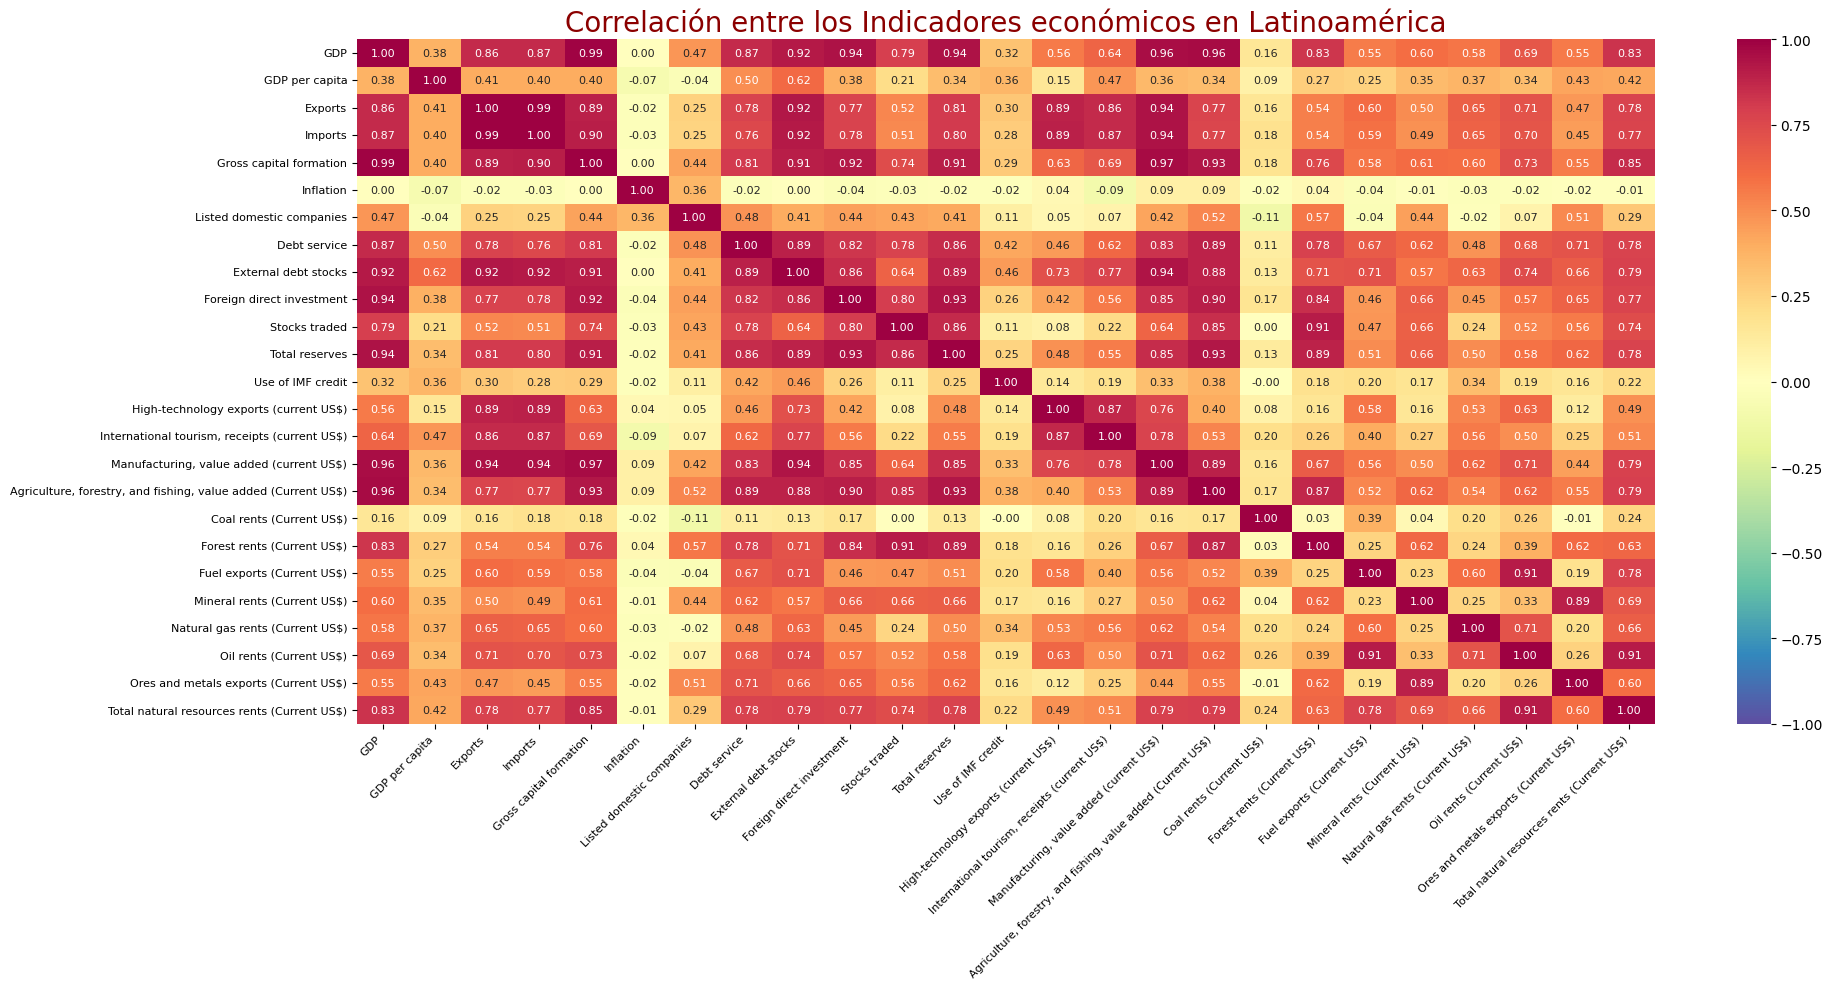

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(20, 10))  # ancho alto
sns.heatmap(
    correlaciones_macro_financ_prodextr,
    annot=True,
    fmt=".2f",
    cmap="Spectral_r",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 8}  # tamaño de letra de los valores anotados
)

plt.title('Correlación entre los Indicadores económicos en Latinoamérica', color='darkred', size=20)
plt.xticks(fontsize=8, rotation=45, ha='right')  # tamaño y orientación etiquetas eje X
plt.yticks(fontsize=8)  # tamaño etiquetas eje Y
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()  # asegura que todo encaje bien
plt.show()


## Hacemos entrar a los indicadores ambientales

In [73]:
import pandas as pd

dim_ambiental= pd.read_csv(r"C:\Users\lulaz\Desktop\IT Academy - Data Analysis\Proyecto Especialización\Indicadores\5. Indicadores Ambientales\dim_ambiental_v1.csv"
                            , decimal=',')
dim_productivo_extractiva 

,Country,Year,High-technology exports (current US$),"International tourism, receipts (current US$)","Manufacturing, value added (current US$)","Agriculture, forestry, and fishing, value added (Current US$)",Coal rents (Current US$),Forest rents (Current US$),Fuel exports (Current US$),Mineral rents (Current US$),Natural gas rents (Current US$),Oil rents (Current US$),Ores and metals exports (Current US$),Total natural resources rents (Current US$)
0,Afghanistan,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14845,Zimbabwe,2019,27782789.0,285000000.0,3.657623e+09,2.525260e+09,6.628791e+07,5.133329e+08,7.979765e+07,6.200663e+08,0.0,1.308567e+07,2.492043e+09,1.212773e+09
14846,Zimbabwe,2020,8275259.0,66000000.0,4.217343e+09,2.357086e+09,5.573196e+07,6.084010e+08,6.606247e+07,6.033724e+08,0.0,7.826441e+06,2.680912e+09,1.275332e+09
14847,Zimbabwe,2021,4788223.0,NaN,3.389519e+09,2.410758e+09,7.903314e+07,4.957481e+08,9.716547e+07,1.155178e+09,0.0,1.301247e+07,2.855750e+09,1.742971e+09
14848,Zimbabwe,2022,7822102.0,NaN,6.732872e+09,2.351205e+09,NaN,NaN,2.645117e+08,NaN,NaN,NaN,3.672581e+09,NaN


In [74]:
Economico_ambiental= pd.merge(macro_financ_prodextr, dim_ambiental, on=["Country", "Year"], how="outer")
Economico_ambiental

,Country,Year,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,...,"Annual freshwater withdrawals, total (billion cubic meters)",Arable land (hectares),Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),Cereal production (metric tons),Fertilizer consumption (kilograms per hectare of arable land),Forest area (sq. km),Land area (sq. km),Level of water stress: freshwater withdrawal as a proportion of available freshwater resources,"Renewable internal freshwater resources, total (billion cubic meters)",Total greenhouse gas emissions including LULUCF (Mt CO2e)
0,Afghanistan,1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7650000.0,NaN,3695000.00,0.143791,NaN,652230.0,NaN,NaN,NaN
1,Afghanistan,1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7700000.0,NaN,3696000.00,0.142857,NaN,652230.0,NaN,47.15,NaN
2,Afghanistan,1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7750000.0,NaN,3378000.00,0.141935,NaN,652230.0,NaN,47.15,NaN
3,Afghanistan,1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7800000.0,NaN,3732000.00,0.141026,NaN,652230.0,NaN,47.15,NaN
4,Afghanistan,1965,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7800000.0,NaN,3785000.00,0.141026,NaN,652230.0,NaN,47.15,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16419,Zimbabwe,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.236264,4000000.0,11.1692,1026006.37,42.386111,174906.5,386850.0,39.769662,12.26,43.61362
16420,Zimbabwe,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.909679,4000000.0,9.0721,1660963.98,32.278234,174445.8,386850.0,46.091620,12.26,42.01482
16421,Zimbabwe,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.909679,4000000.0,10.6233,2043436.41,33.771180,173985.1,386850.0,46.091620,12.26,44.12262
16422,Zimbabwe,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,10.9630,1887719.54,33.330587,173524.4,386850.0,NaN,NaN,45.06962


In [75]:
Latam_Economico_ambiental=pd.merge(macro_financ_prodextr, dim_ambiental, on=["Country", "Year"], how="inner")
Latam_Economico_ambiental.to_csv('Economico_ambiental.csv', decimal=',', index=False)
Latam_Economico_ambiental


,Country,Year,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,...,"Annual freshwater withdrawals, total (billion cubic meters)",Arable land (hectares),Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),Cereal production (metric tons),Fertilizer consumption (kilograms per hectare of arable land),Forest area (sq. km),Land area (sq. km),Level of water stress: freshwater withdrawal as a proportion of available freshwater resources,"Renewable internal freshwater resources, total (billion cubic meters)",Total greenhouse gas emissions including LULUCF (Mt CO2e)
0,Argentina,1990,1.413526e+11,4315.333294,1.464348e+10,6.546496e+09,1.978510e+10,NaN,178.0,6.184791e+09,...,28.321405,26575000.0,100.1876,19142700.00,6.227658,352040.0,2736690.0,7.857453,292.0,NaN
1,Argentina,1991,1.897200e+11,5709.247841,1.456109e+10,1.153120e+10,2.776927e+10,NaN,169.0,5.449279e+09,...,28.373132,26680000.0,105.5928,22838060.00,6.270615,350214.0,2736690.0,7.871804,292.0,NaN
2,Argentina,1992,2.287789e+11,6789.996111,1.509526e+10,1.860612e+10,3.821158e+10,NaN,170.0,4.914055e+09,...,28.424674,26785000.0,107.5110,25622020.00,9.266380,348388.0,2736690.0,7.886104,292.0,NaN
3,Argentina,1993,2.367417e+11,6931.855964,1.635732e+10,2.204965e+10,4.660997e+10,NaN,165.0,5.872302e+09,...,28.476216,26890000.0,111.2743,25568081.00,10.929714,346562.0,2736690.0,7.900404,292.0,NaN
4,Argentina,1994,2.574400e+11,7437.562423,1.938510e+10,2.729996e+10,5.139950e+10,NaN,156.0,5.783539e+09,...,28.527758,26998000.0,114.6833,23789591.00,17.112379,344736.0,2736690.0,7.914704,292.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,"Venezuela, RB",2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.621100,2600000.0,119.4988,1579755.00,47.139669,462720.0,882050.0,7.540367,805.0,157.3669
574,"Venezuela, RB",2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.621100,2600000.0,72.3292,2396627.73,53.975877,462309.0,882050.0,7.540367,805.0,106.0976
575,"Venezuela, RB",2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.621100,2600000.0,71.1775,2310487.53,50.886512,461733.6,882050.0,7.540367,805.0,104.4542
576,"Venezuela, RB",2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,77.8470,1868483.97,50.886512,461267.8,882050.0,NaN,NaN,113.6750


### Latinoamericanizamos

In [76]:
Latam_ambiental=dim_ambiental[dim_ambiental['Country'].isin(['Argentina', 'Bolivia', 'Brazil','Chile','Colombia', 'Costa Rica','Dominican Republic','Ecuador', 'El Salvador','Guatemala', 'Honduras', 'Mexico', 'Panama','Paraguay', 'Peru','Uruguay', 
                         'Venezuela, RB'  ])]
Latam_ambiental['Year']=Latam_ambiental["Year"].astype(int)
Latam_ambiental=Latam_ambiental[Latam_ambiental["Year"] >= 1990]
Latam_ambiental

C:\Users\lulaz\AppData\Local\Temp\ipykernel_44296\817879845.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Latam_ambiental['Year']=Latam_ambiental["Year"].astype(int)


,Country,Year,Agricultural land (sq. km),"Annual freshwater withdrawals, total (billion cubic meters)",Arable land (hectares),Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),Cereal production (metric tons),Fertilizer consumption (kilograms per hectare of arable land),Forest area (sq. km),Land area (sq. km),Level of water stress: freshwater withdrawal as a proportion of available freshwater resources,"Renewable internal freshwater resources, total (billion cubic meters)",Total greenhouse gas emissions including LULUCF (Mt CO2e)
658,Argentina,1990,1275650.0,28.321405,26575000.0,100.1876,19142700.00,6.227658,352040.0,2736690.0,7.857453,292.0,NaN
659,Argentina,1991,1276600.0,28.373132,26680000.0,105.5928,22838060.00,6.270615,350214.0,2736690.0,7.871804,292.0,NaN
660,Argentina,1992,1277550.0,28.424674,26785000.0,107.5110,25622020.00,9.266380,348388.0,2736690.0,7.886104,292.0,NaN
661,Argentina,1993,1278500.0,28.476216,26890000.0,111.2743,25568081.00,10.929714,346562.0,2736690.0,7.900404,292.0,NaN
662,Argentina,1994,1279480.0,28.527758,26998000.0,114.6833,23789591.00,17.112379,344736.0,2736690.0,7.914704,292.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15963,"Venezuela, RB",2019,215000.0,22.621100,2600000.0,119.4988,1579755.00,47.139669,462720.0,882050.0,7.540367,805.0,157.3669
15964,"Venezuela, RB",2020,215000.0,22.621100,2600000.0,72.3292,2396627.73,53.975877,462309.0,882050.0,7.540367,805.0,106.0976
15965,"Venezuela, RB",2021,215000.0,22.621100,2600000.0,71.1775,2310487.53,50.886512,461733.6,882050.0,7.540367,805.0,104.4542
15966,"Venezuela, RB",2022,NaN,NaN,NaN,77.8470,1868483.97,50.886512,461267.8,882050.0,NaN,NaN,113.6750


## Unimos a todos los indicadores económicos previos


In [115]:
macro_financ_prodextr
Latam_ambiental

,Country,Year,Agricultural land (sq. km),"Annual freshwater withdrawals, total (billion cubic meters)",Arable land (hectares),Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),Cereal production (metric tons),Fertilizer consumption (kilograms per hectare of arable land),Forest area (sq. km),Land area (sq. km),Level of water stress: freshwater withdrawal as a proportion of available freshwater resources,"Renewable internal freshwater resources, total (billion cubic meters)",Total greenhouse gas emissions including LULUCF (Mt CO2e)
658,Argentina,1990,1275650.0,28.321405,26575000.0,100.1876,19142700.00,6.227658,352040.0,2736690.0,7.857453,292.0,NaN
659,Argentina,1991,1276600.0,28.373132,26680000.0,105.5928,22838060.00,6.270615,350214.0,2736690.0,7.871804,292.0,NaN
660,Argentina,1992,1277550.0,28.424674,26785000.0,107.5110,25622020.00,9.266380,348388.0,2736690.0,7.886104,292.0,NaN
661,Argentina,1993,1278500.0,28.476216,26890000.0,111.2743,25568081.00,10.929714,346562.0,2736690.0,7.900404,292.0,NaN
662,Argentina,1994,1279480.0,28.527758,26998000.0,114.6833,23789591.00,17.112379,344736.0,2736690.0,7.914704,292.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15963,"Venezuela, RB",2019,215000.0,22.621100,2600000.0,119.4988,1579755.00,47.139669,462720.0,882050.0,7.540367,805.0,157.3669
15964,"Venezuela, RB",2020,215000.0,22.621100,2600000.0,72.3292,2396627.73,53.975877,462309.0,882050.0,7.540367,805.0,106.0976
15965,"Venezuela, RB",2021,215000.0,22.621100,2600000.0,71.1775,2310487.53,50.886512,461733.6,882050.0,7.540367,805.0,104.4542
15966,"Venezuela, RB",2022,NaN,NaN,NaN,77.8470,1868483.97,50.886512,461267.8,882050.0,NaN,NaN,113.6750


In [116]:
Latam_Economico_ambiental= pd.merge(macro_financ_prodextr, Latam_ambiental, on=["Country", "Year"], how="outer")
print(Latam_Economico_ambiental.columns)

Index(['Country', 'Year', 'GDP', 'GDP per capita', 'Exports', 'Imports',
       'Gross capital formation', 'Inflation', 'Listed domestic companies',
       'Debt service', 'External debt stocks', 'Foreign direct investment',
       'Stocks traded', 'Total reserves', 'Use of IMF credit',
       'High-technology exports (current US$)',
       'International tourism, receipts (current US$)',
       'Manufacturing, value added (current US$)',
       'Agriculture, forestry, and fishing, value added (Current US$)',
       'Coal rents (Current US$)', 'Forest rents (Current US$)',
       'Fuel exports (Current US$)', 'Mineral rents (Current US$)',
       'Natural gas rents (Current US$)', 'Oil rents (Current US$)',
       'Ores and metals exports (Current US$)',
       'Total natural resources rents (Current US$)',
       'Agricultural land (sq. km)',
       'Annual freshwater withdrawals, total (billion cubic meters)',
       'Arable land (hectares)',
       'Carbon dioxide (CO2) emissions (t

In [117]:
Latam_Economico_ambiental

,Country,Year,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,...,"Annual freshwater withdrawals, total (billion cubic meters)",Arable land (hectares),Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),Cereal production (metric tons),Fertilizer consumption (kilograms per hectare of arable land),Forest area (sq. km),Land area (sq. km),Level of water stress: freshwater withdrawal as a proportion of available freshwater resources,"Renewable internal freshwater resources, total (billion cubic meters)",Total greenhouse gas emissions including LULUCF (Mt CO2e)
0,Argentina,1990,1.413526e+11,4315.333294,1.464348e+10,6.546496e+09,1.978510e+10,NaN,178.0,6.184791e+09,...,28.321405,26575000.0,100.1876,19142700.00,6.227658,352040.0,2736690.0,7.857453,292.0,NaN
1,Argentina,1991,1.897200e+11,5709.247841,1.456109e+10,1.153120e+10,2.776927e+10,NaN,169.0,5.449279e+09,...,28.373132,26680000.0,105.5928,22838060.00,6.270615,350214.0,2736690.0,7.871804,292.0,NaN
2,Argentina,1992,2.287789e+11,6789.996111,1.509526e+10,1.860612e+10,3.821158e+10,NaN,170.0,4.914055e+09,...,28.424674,26785000.0,107.5110,25622020.00,9.266380,348388.0,2736690.0,7.886104,292.0,NaN
3,Argentina,1993,2.367417e+11,6931.855964,1.635732e+10,2.204965e+10,4.660997e+10,NaN,165.0,5.872302e+09,...,28.476216,26890000.0,111.2743,25568081.00,10.929714,346562.0,2736690.0,7.900404,292.0,NaN
4,Argentina,1994,2.574400e+11,7437.562423,1.938510e+10,2.729996e+10,5.139950e+10,NaN,156.0,5.783539e+09,...,28.527758,26998000.0,114.6833,23789591.00,17.112379,344736.0,2736690.0,7.914704,292.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,"Venezuela, RB",2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.621100,2600000.0,119.4988,1579755.00,47.139669,462720.0,882050.0,7.540367,805.0,157.3669
590,"Venezuela, RB",2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.621100,2600000.0,72.3292,2396627.73,53.975877,462309.0,882050.0,7.540367,805.0,106.0976
591,"Venezuela, RB",2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.621100,2600000.0,71.1775,2310487.53,50.886512,461733.6,882050.0,7.540367,805.0,104.4542
592,"Venezuela, RB",2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,77.8470,1868483.97,50.886512,461267.8,882050.0,NaN,NaN,113.6750


In [118]:
import plotly.express as px

# Hacemos una copia del dataframe para no modificar el original
df_plot = Latam_Economico_ambiental.copy()

# Lista de columnas que vas a usar
columns = [
    'GDP', 'Exports', 'Arable land (hectares)',
    'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)',
    'Forest area (sq. km)', 'Land area (sq. km)',
    'Level of water stress: freshwater withdrawal as a proportion of available freshwater resources'
]

# Renombrar columnas truncándolas a 15 caracteres
short_names = {col: col[:23] for col in columns}
df_plot = df_plot.rename(columns=short_names)

# Scatter matrix con nombres truncados
fig = px.scatter_matrix(
    df_plot,
    dimensions=[short_names[col] for col in columns],
    color="Country",
    width=1200,
    height=1200
)

# Cambiar el tamaño de fuente
fig.update_layout(font=dict(size=9))

fig.show()


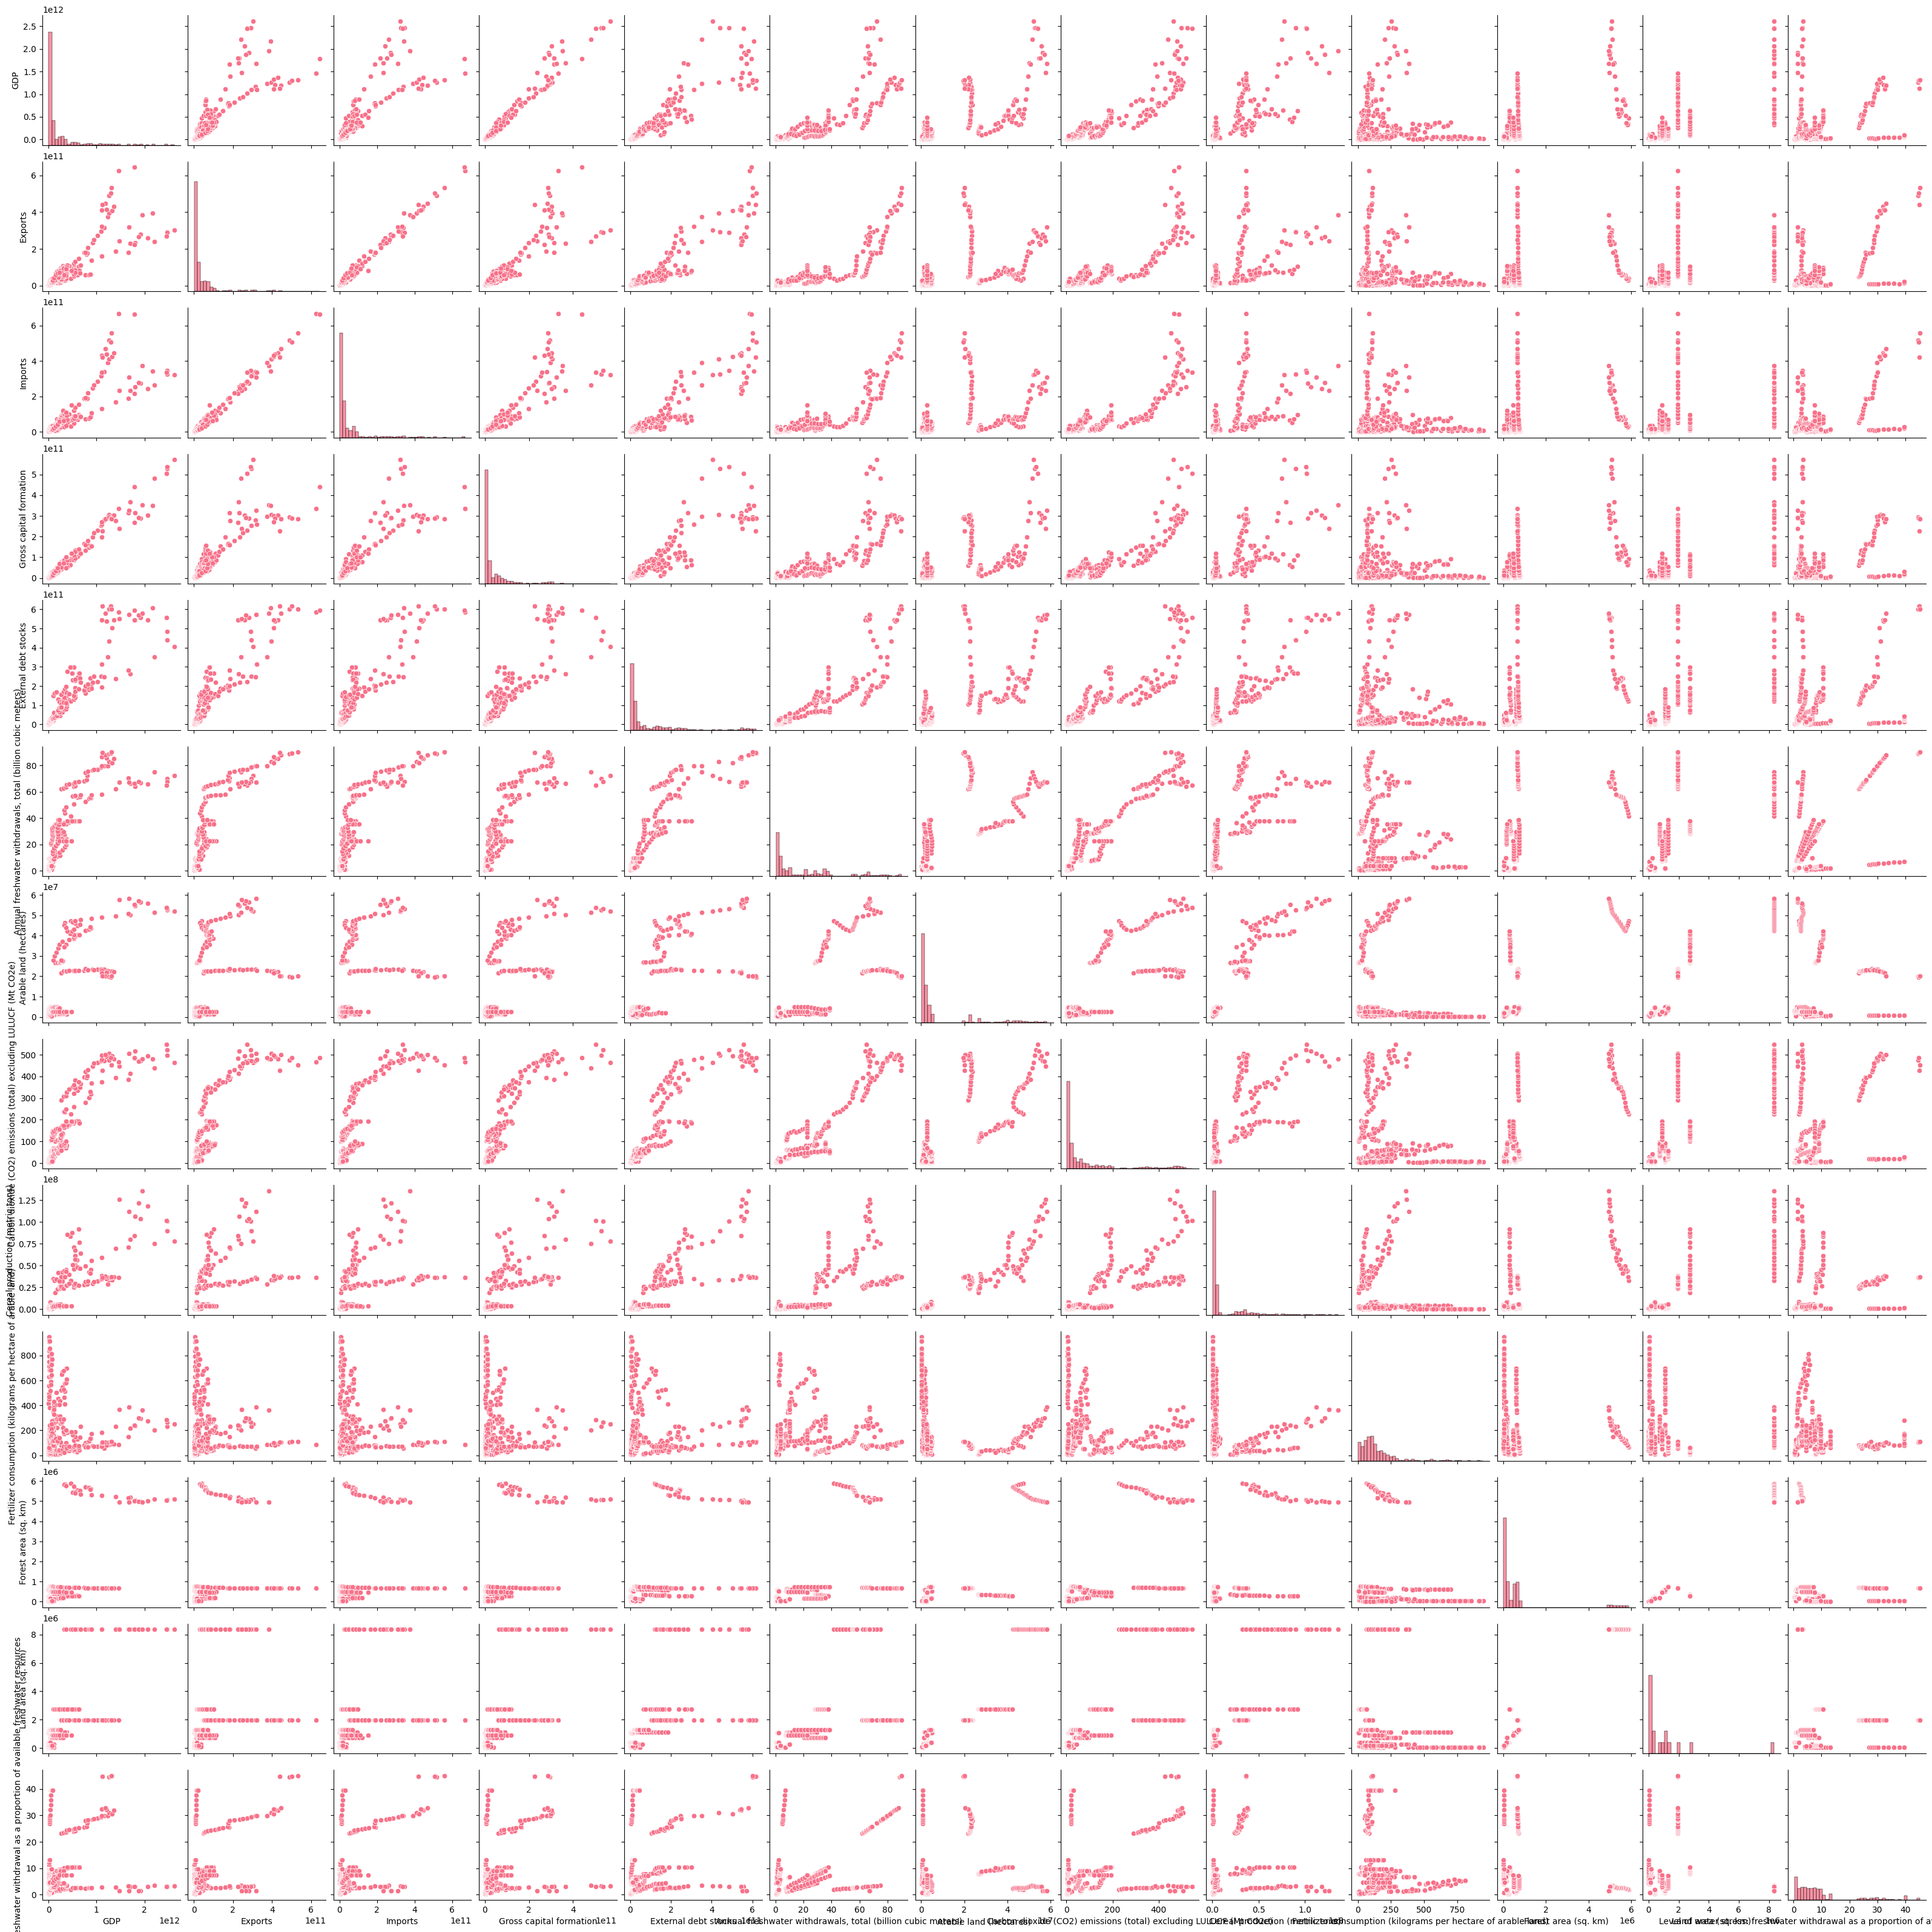

In [119]:
df_comparativo=Latam_Economico_ambiental[['GDP', 'Exports', 'Imports',
       'Gross capital formation', 'External debt stocks', 'Annual freshwater withdrawals, total (billion cubic meters)',
       'Arable land (hectares)',
       'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)',
       'Cereal production (metric tons)',
       'Fertilizer consumption (kilograms per hectare of arable land)',
       'Forest area (sq. km)', 'Land area (sq. km)',
       'Level of water stress: freshwater withdrawal as a proportion of available freshwater resources']]

sns.pairplot(df_comparativo, diag_kws={'bins':40});
sns.set_palette("husl")

Text(0.5, 1.0, 'GDP y Nivel de Estress Hídrico')

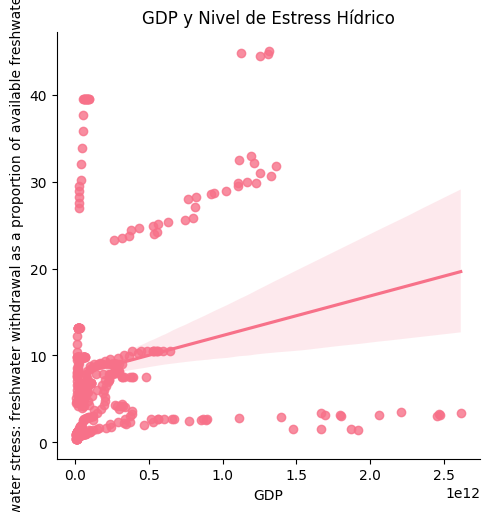

In [120]:
sns.lmplot(data=Latam_Economico_ambiental, x="GDP", y="Level of water stress: freshwater withdrawal as a proportion of available freshwater resources")
sns.set_palette("husl")
plt.title('GDP y Nivel de Estress Hídrico')

In [121]:
fig = px.scatter(
    Latam_Economico_ambiental,
    x="GDP",
    y="Forest area (sq. km)",
    color="Country",
    title="Evolución temporal: GDP vs Área Forestal en América Latina"
)

fig.show()

In [122]:
fig = px.scatter(
    Latam_Economico_ambiental,
    x="GDP",
    y="Forest area (sq. km)",
    color="Year",
    hover_name="Country",
    facet_col="Country",
    log_x=True,
    title="Evolución del GDP y Área Forestal por País (con facetas)"
)

fig.show()


In [123]:
print(Latam_Economico_ambiental.columns)

Index(['Country', 'Year', 'GDP', 'GDP per capita', 'Exports', 'Imports',
       'Gross capital formation', 'Inflation', 'Listed domestic companies',
       'Debt service', 'External debt stocks', 'Foreign direct investment',
       'Stocks traded', 'Total reserves', 'Use of IMF credit',
       'High-technology exports (current US$)',
       'International tourism, receipts (current US$)',
       'Manufacturing, value added (current US$)',
       'Agriculture, forestry, and fishing, value added (Current US$)',
       'Coal rents (Current US$)', 'Forest rents (Current US$)',
       'Fuel exports (Current US$)', 'Mineral rents (Current US$)',
       'Natural gas rents (Current US$)', 'Oil rents (Current US$)',
       'Ores and metals exports (Current US$)',
       'Total natural resources rents (Current US$)',
       'Agricultural land (sq. km)',
       'Annual freshwater withdrawals, total (billion cubic meters)',
       'Arable land (hectares)',
       'Carbon dioxide (CO2) emissions (t

## Vamos a las correlaciones


In [90]:
numericas=['GDP', 'GDP per capita', 'Exports', 'Imports',
       'Gross capital formation', 'Inflation', 'Listed domestic companies',
       'Debt service', 'External debt stocks', 'Foreign direct investment',
       'Stocks traded', 'Total reserves', 'Use of IMF credit',
       'High-technology exports (current US$)',
       'International tourism, receipts (current US$)',
       'Manufacturing, value added (current US$)',
       'Agriculture, forestry, and fishing, value added (Current US$)',
       'Coal rents (Current US$)', 'Forest rents (Current US$)',
       'Fuel exports (Current US$)', 'Mineral rents (Current US$)',
       'Natural gas rents (Current US$)', 'Oil rents (Current US$)',
       'Ores and metals exports (Current US$)',
       'Total natural resources rents (Current US$)',
       'Agricultural land (sq. km)',
       'Annual freshwater withdrawals, total (billion cubic meters)',
       'Arable land (hectares)',
       'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)',
       'Cereal production (metric tons)',
       'Fertilizer consumption (kilograms per hectare of arable land)',
       'Forest area (sq. km)', 'Land area (sq. km)',
       'Level of water stress: freshwater withdrawal as a proportion of available freshwater resources',
       'Renewable internal freshwater resources, total (billion cubic meters)',
       'Total greenhouse gas emissions including LULUCF (Mt CO2e)']

Latam_Economico_ambiental_num=Latam_Economico_ambiental[numericas]
Latam_Economico_ambiental_num

,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,External debt stocks,Foreign direct investment,...,"Annual freshwater withdrawals, total (billion cubic meters)",Arable land (hectares),Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),Cereal production (metric tons),Fertilizer consumption (kilograms per hectare of arable land),Forest area (sq. km),Land area (sq. km),Level of water stress: freshwater withdrawal as a proportion of available freshwater resources,"Renewable internal freshwater resources, total (billion cubic meters)",Total greenhouse gas emissions including LULUCF (Mt CO2e)
0,1.413526e+11,4315.333294,1.464348e+10,6.546496e+09,1.978510e+10,NaN,178.0,6.184791e+09,6.247760e+10,1.836000e+09,...,28.321405,26575000.0,100.1876,19142700.00,6.227658,352040.0,2736690.0,7.857453,292.0,NaN
1,1.897200e+11,5709.247841,1.456109e+10,1.153120e+10,2.776927e+10,NaN,169.0,5.449279e+09,6.567237e+10,2.439000e+09,...,28.373132,26680000.0,105.5928,22838060.00,6.270615,350214.0,2736690.0,7.871804,292.0,NaN
2,2.287789e+11,6789.996111,1.509526e+10,1.860612e+10,3.821158e+10,NaN,170.0,4.914055e+09,6.860564e+10,4.430978e+09,...,28.424674,26785000.0,107.5110,25622020.00,9.266380,348388.0,2736690.0,7.886104,292.0,NaN
3,2.367417e+11,6931.855964,1.635732e+10,2.204965e+10,4.660997e+10,NaN,165.0,5.872302e+09,6.468139e+10,2.793085e+09,...,28.476216,26890000.0,111.2743,25568081.00,10.929714,346562.0,2736690.0,7.900404,292.0,NaN
4,2.574400e+11,7437.562423,1.938510e+10,2.729996e+10,5.139950e+10,NaN,156.0,5.783539e+09,7.509406e+10,3.634932e+09,...,28.527758,26998000.0,114.6833,23789591.00,17.112379,344736.0,2736690.0,7.914704,292.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.367000e+09,...,22.621100,2600000.0,119.4988,1579755.00,47.139669,462720.0,882050.0,7.540367,805.0,157.3669
590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.504000e+09,...,22.621100,2600000.0,72.3292,2396627.73,53.975877,462309.0,882050.0,7.540367,805.0,106.0976
591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.640000e+08,...,22.621100,2600000.0,71.1775,2310487.53,50.886512,461733.6,882050.0,7.540367,805.0,104.4542
592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.651000e+09,...,NaN,NaN,77.8470,1868483.97,50.886512,461267.8,882050.0,NaN,NaN,113.6750


In [91]:
correlaciones_Latam_Economico_ambiental_num=Latam_Economico_ambiental_num.corr()
correlaciones_Latam_Economico_ambiental_num

,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,External debt stocks,Foreign direct investment,...,"Annual freshwater withdrawals, total (billion cubic meters)",Arable land (hectares),Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),Cereal production (metric tons),Fertilizer consumption (kilograms per hectare of arable land),Forest area (sq. km),Land area (sq. km),Level of water stress: freshwater withdrawal as a proportion of available freshwater resources,"Renewable internal freshwater resources, total (billion cubic meters)",Total greenhouse gas emissions including LULUCF (Mt CO2e)
GDP,1.000000,0.379989,0.863227,0.865388,0.985630,0.003164,0.471059,0.865526,0.920276,0.939368,...,0.830402,0.793269,0.909297,0.853255,0.043831,0.696819,0.768684,0.202150,0.649068,0.730737
GDP per capita,0.379989,1.000000,0.405819,0.399983,0.403013,-0.073015,-0.043782,0.498135,0.616371,0.383532,...,0.331321,0.246573,0.313552,0.299599,0.218548,0.054274,0.142824,0.190612,0.071287,0.093675
Exports,0.863227,0.405819,1.000000,0.994772,0.894366,-0.023942,0.251199,0.776134,0.922404,0.773480,...,0.849176,0.576475,0.863325,0.640565,0.010538,0.405522,0.489443,0.439546,0.358375,0.516582
Imports,0.865388,0.399983,0.994772,1.000000,0.902031,-0.027396,0.247727,0.757557,0.916726,0.778487,...,0.841974,0.566193,0.859407,0.628657,0.017590,0.400534,0.479977,0.446887,0.356531,0.497312
Gross capital formation,0.985630,0.403013,0.894366,0.902031,1.000000,0.002274,0.435248,0.810930,0.905874,0.919083,...,0.840505,0.737521,0.909321,0.789685,0.038762,0.640594,0.710252,0.252184,0.595436,0.676502
Inflation,0.003164,-0.073015,-0.023942,-0.027396,0.002274,1.000000,0.363452,-0.024125,0.001231,-0.037246,...,0.111201,0.126157,0.035968,0.051050,-0.058992,0.180987,0.160292,-0.069088,0.173386,0.019158
Listed domestic companies,0.471059,-0.043782,0.251199,0.247727,0.435248,0.363452,1.000000,0.476853,0.406091,0.442744,...,0.511302,0.601299,0.485477,0.508912,-0.235119,0.778342,0.770377,-0.078577,0.766319,0.665173
Debt service,0.865526,0.498135,0.776134,0.757557,0.810930,-0.024125,0.476853,1.000000,0.893497,0.823125,...,0.807268,0.775807,0.842231,0.863128,0.037417,0.667838,0.741680,0.181330,0.619445,0.768095
External debt stocks,0.920276,0.616371,0.922404,0.916726,0.905874,0.001231,0.406091,0.893497,1.000000,0.856940,...,0.877915,0.767874,0.913350,0.837496,-0.010931,0.574033,0.680600,0.301054,0.523301,0.652899
Foreign direct investment,0.939368,0.383532,0.773480,0.778487,0.919083,-0.037246,0.442744,0.823125,0.856940,1.000000,...,0.720947,0.681583,0.793805,0.771315,0.107693,0.640847,0.694544,0.131929,0.622571,0.679110


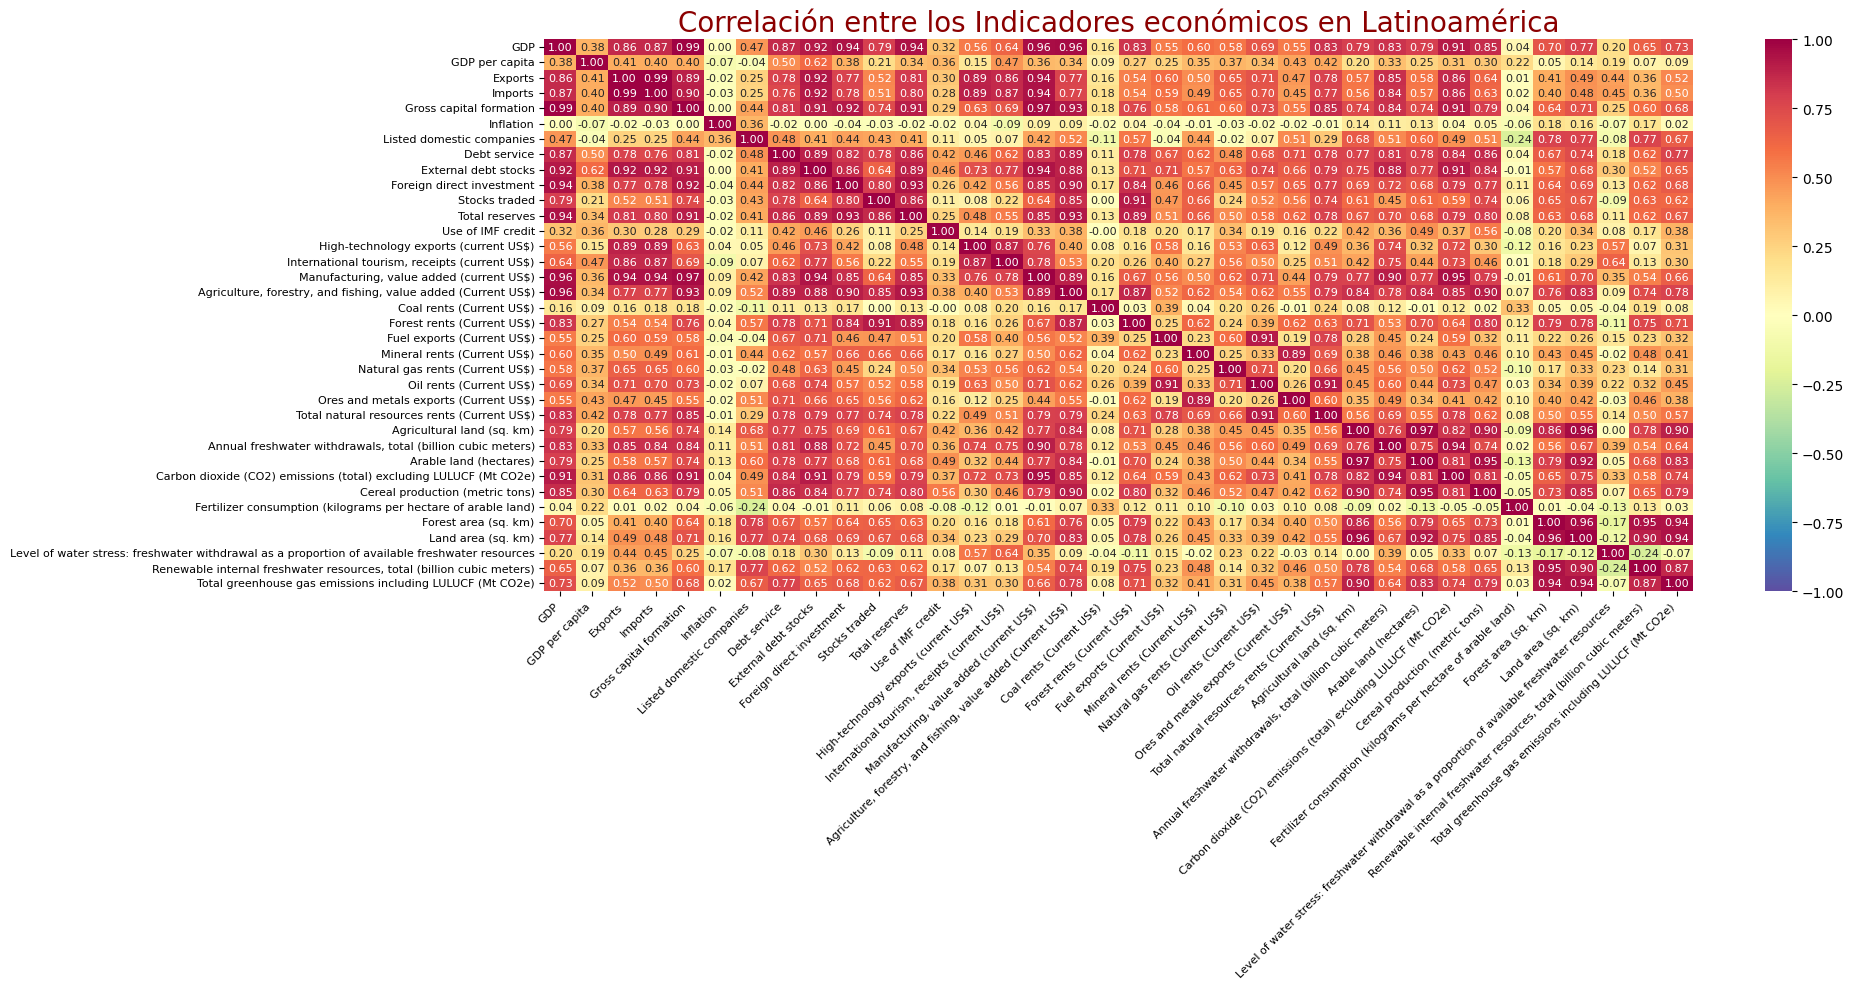

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(20, 10))  # ancho alto
sns.heatmap(
    correlaciones_Latam_Economico_ambiental_num,
    annot=True,
    fmt=".2f",
    cmap="Spectral_r",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 8}  # tamaño de letra de los valores anotados
)

plt.title('Correlación entre los Indicadores económicos en Latinoamérica', color='darkred', size=20)
plt.xticks(fontsize=8, rotation=45, ha='right')  # tamaño y orientación etiquetas eje X
plt.yticks(fontsize=8)  # tamaño etiquetas eje Y
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()  # asegura que todo encaje bien
plt.show()


## Jugamos a los componentes principales

In [94]:
print(Latam_Economico_ambiental_num.columns)


Index(['GDP', 'GDP per capita', 'Exports', 'Imports',
       'Gross capital formation', 'Inflation', 'Listed domestic companies',
       'Debt service', 'External debt stocks', 'Foreign direct investment',
       'Stocks traded', 'Total reserves', 'Use of IMF credit',
       'High-technology exports (current US$)',
       'International tourism, receipts (current US$)',
       'Manufacturing, value added (current US$)',
       'Agriculture, forestry, and fishing, value added (Current US$)',
       'Coal rents (Current US$)', 'Forest rents (Current US$)',
       'Fuel exports (Current US$)', 'Mineral rents (Current US$)',
       'Natural gas rents (Current US$)', 'Oil rents (Current US$)',
       'Ores and metals exports (Current US$)',
       'Total natural resources rents (Current US$)',
       'Agricultural land (sq. km)',
       'Annual freshwater withdrawals, total (billion cubic meters)',
       'Arable land (hectares)',
       'Carbon dioxide (CO2) emissions (total) excluding LUL

In [95]:
columnas=['GDP', 'GDP per capita', 'Exports', 'Imports',
       'Gross capital formation', 'Inflation', 'Listed domestic companies',
       'Debt service', 'External debt stocks', 'Foreign direct investment',
       'Stocks traded', 'Total reserves', 'Use of IMF credit',
       'High-technology exports (current US$)',
       'International tourism, receipts (current US$)',
       'Manufacturing, value added (current US$)',
       'Agriculture, forestry, and fishing, value added (Current US$)',
       'Coal rents (Current US$)', 'Forest rents (Current US$)',
       'Fuel exports (Current US$)', 'Mineral rents (Current US$)',
       'Natural gas rents (Current US$)', 'Oil rents (Current US$)',
       'Ores and metals exports (Current US$)',
       'Total natural resources rents (Current US$)',
       'Agricultural land (sq. km)',
       'Annual freshwater withdrawals, total (billion cubic meters)',
       'Arable land (hectares)',
       'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)',
       'Cereal production (metric tons)',
       'Fertilizer consumption (kilograms per hectare of arable land)',
       'Forest area (sq. km)', 'Land area (sq. km)',
       'Level of water stress: freshwater withdrawal as a proportion of available freshwater resources',
       'Renewable internal freshwater resources, total (billion cubic meters)',
       'Total greenhouse gas emissions including LULUCF (Mt CO2e)']

## CAUSALIDAD
Granger Causality Test	

In [110]:
from statsmodels.tsa.stattools import grangercausalitytests
import pandas as pd

def grangers_causality_matrix(data, variables, maxlag=2, test='ssr_chi2test'):
    """
    Retorna un DataFrame donde [X causa Y] basado en el p-value de Granger Causality Test
    """
    matriz = pd.DataFrame(index=variables, columns=variables, dtype=float)  # 👈 Aquí forzamos float
    for c in matriz.columns:
        for r in matriz.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1], 4) for i in range(maxlag)]
            min_p_value = min(p_values)
            matriz.loc[r, c] = min_p_value
    return matriz

# Usar
variables = vars_std.columns.tolist()  # O selecciona solo las numéricas si hay texto
causalidad = grangers_causality_matrix(vars_std, variables, maxlag=2)

causalidad


C:\Users\lulaz\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results

C:\Users\lulaz\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results

C:\Users\lulaz\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results

C:\Users\lulaz\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results

C:\Users\lulaz\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results

C:\Users\lulaz\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning:

ve

,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,External debt stocks,Foreign direct investment,...,"Annual freshwater withdrawals, total (billion cubic meters)",Arable land (hectares),Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),Cereal production (metric tons),Fertilizer consumption (kilograms per hectare of arable land),Forest area (sq. km),Land area (sq. km),Level of water stress: freshwater withdrawal as a proportion of available freshwater resources,"Renewable internal freshwater resources, total (billion cubic meters)",Total greenhouse gas emissions including LULUCF (Mt CO2e)
GDP,1.0000,0.0932,0.0000,0.0000,0.0991,0.6409,0.0000,0.0000,0.3189,0.0001,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0013,0.0000,0.0000
GDP per capita,0.8581,1.0000,0.7239,0.3731,0.9860,0.8521,0.0000,0.0551,0.7034,0.0500,...,0.0000,0.0037,0.3852,0.0000,0.0000,0.0001,0.0000,0.0000,0.0990,0.0000
Exports,0.0000,0.0656,1.0000,0.0000,0.0000,0.9576,0.0000,0.0000,0.0023,0.0017,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Imports,0.0000,0.0304,0.0001,1.0000,0.0000,0.8983,0.0000,0.0000,0.0005,0.0054,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Gross capital formation,0.1244,0.0924,0.0014,0.0000,1.0000,0.8170,0.0000,0.0000,0.6974,0.0079,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Inflation,0.6223,0.0014,0.4755,0.4588,0.6101,1.0000,0.2220,0.5753,0.7083,0.4337,...,0.9250,0.4826,0.8892,0.9067,0.1924,0.0966,0.2495,0.2749,0.2452,0.4890
Listed domestic companies,0.0000,0.0001,0.0001,0.0002,0.0029,0.6110,1.0000,0.0187,0.0010,0.0691,...,0.0000,0.0000,0.0001,0.2599,0.1031,0.1589,0.3266,0.0257,0.0000,0.7839
Debt service,0.0000,0.2074,0.0000,0.0000,0.0000,0.8385,0.0000,1.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0221,0.0000,0.0000
External debt stocks,0.0000,0.1496,0.0147,0.0237,0.0001,0.8323,0.0000,0.0000,0.9096,0.0125,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0001,0.0000,0.0000
Foreign direct investment,0.0000,0.0052,0.0000,0.0000,0.0000,0.9376,0.0000,0.0000,0.0000,1.0000,...,0.0000,0.0000,0.0000,0.0000,0.0417,0.0000,0.0000,0.0183,0.0000,0.0000


Si el número es pequeño (p-value < 0.05) ➔
→ Hay evidencia estadística de causalidad ➔ podemos decir que la variable de la fila causa a la de la columna.

Si el número es grande (p-value > 0.05) ➔
→ No hay evidencia fuerte de causalidad.

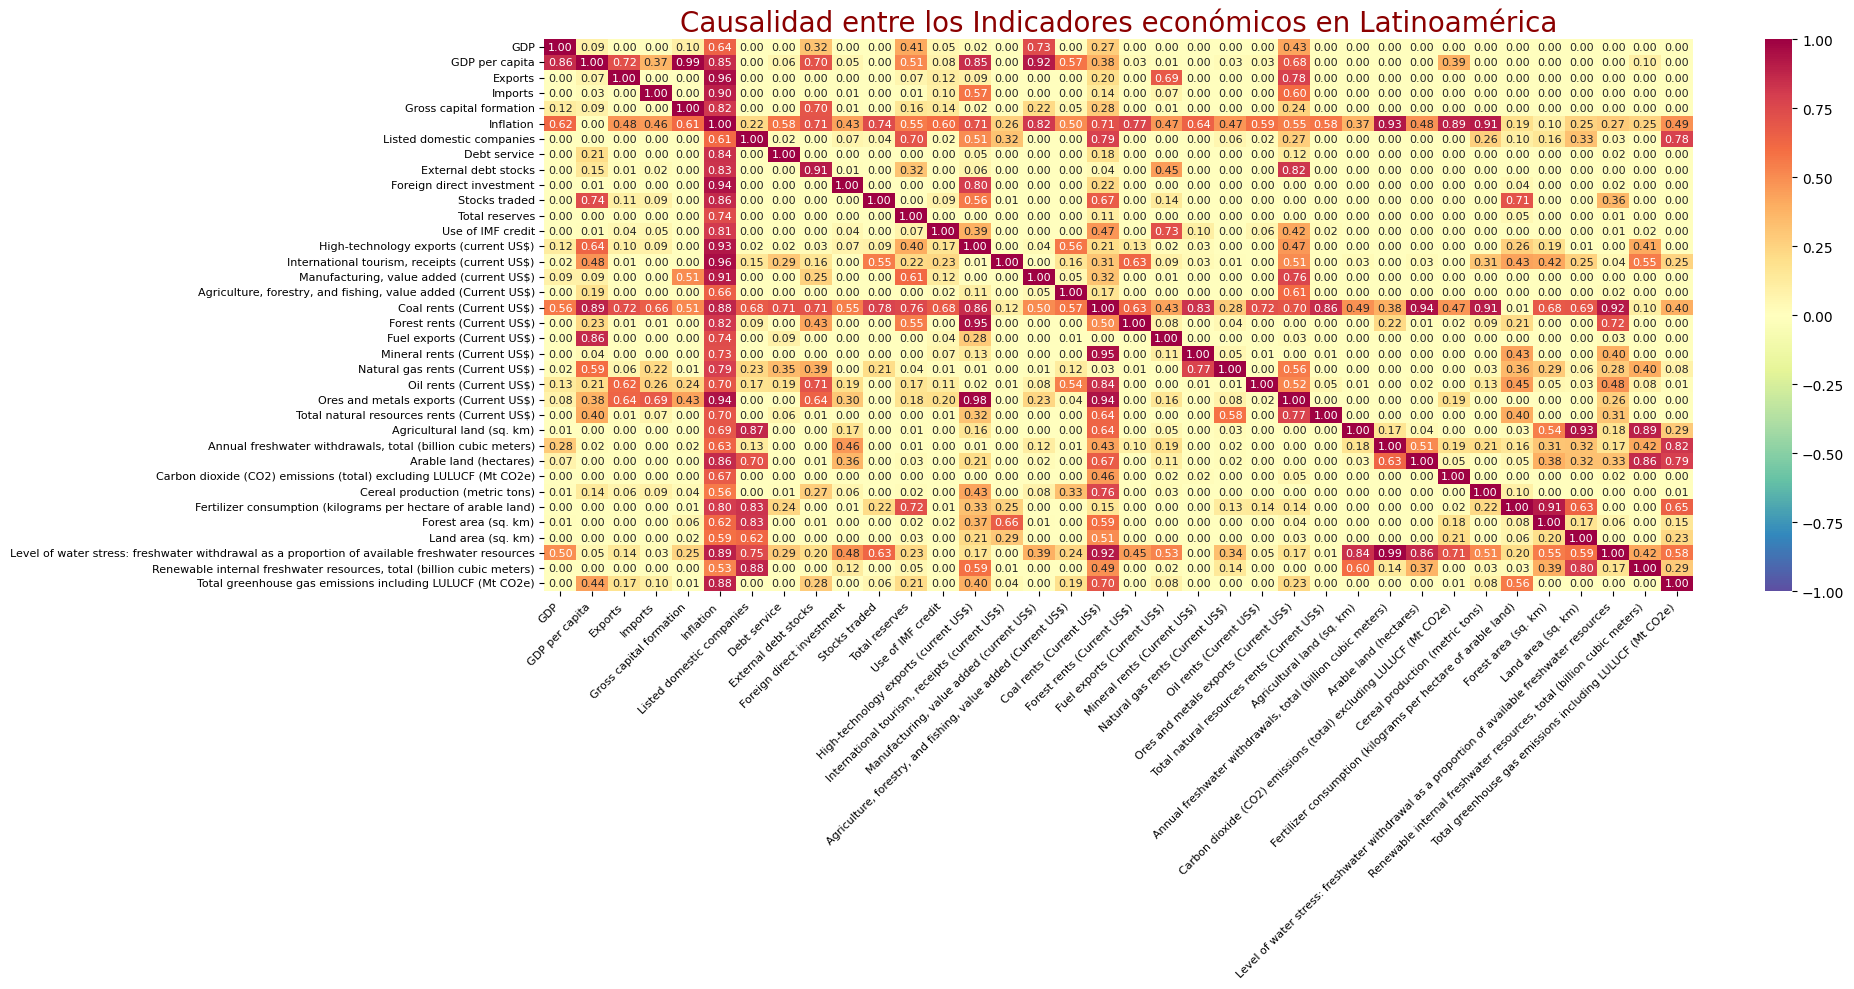

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(20, 10))  # ancho alto
sns.heatmap(
    causalidad,
    annot=True,
    fmt=".2f",
    cmap="Spectral_r",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 8}  # tamaño de letra de los valores anotados
)

plt.title('Causalidad entre los Indicadores económicos en Latinoamérica', color='darkred', size=20)
plt.xticks(fontsize=8, rotation=45, ha='right')  # tamaño y orientación etiquetas eje X
plt.yticks(fontsize=8)  # tamaño etiquetas eje Y
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()  # asegura que todo encaje bien
plt.show()


## COMPONENTES PRINCIPALES

In [102]:
# Subset
vars_pca = Latam_Economico_ambiental_num[columnas]

# Verificar columnas
print(vars_pca.shape)  # debería ser (n_observaciones, 25)

# Estandarizar
vars_std = vars_pca.fillna(0)
vars_std = (vars_std - vars_std.mean()) / vars_std.std()

# Covarianza y PCA
cov_matrix = np.cov(vars_std.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

# Loadings
loadings = eigenvectors * np.sqrt(eigenvalues)

# DataFrame de loadings
loadings_df = pd.DataFrame(loadings,
                           index=columnas,
                           columns=[f'PC{i+1}' for i in range(len(eigenvalues))])

# Mostramos las primeras 5 PCs
print(loadings_df.iloc[:, :5].round(3))


(594, 36)
                                                      PC1    PC2    PC3  \
GDP                                                -0.971  0.061 -0.060   
GDP per capita                                     -0.383  0.292 -0.284   
Exports                                            -0.846  0.442 -0.014   
Imports                                            -0.841  0.448 -0.013   
Gross capital formation                            -0.955  0.151 -0.078   
Inflation                                          -0.029 -0.195  0.187   
Listed domestic companies                          -0.654 -0.435  0.047   
Debt service                                       -0.861  0.005  0.059   
External debt stocks                               -0.911  0.180  0.155   
Foreign direct investment                          -0.887 -0.005 -0.228   
Stocks traded                                      -0.762 -0.296 -0.285   
Total reserves                                     -0.880  0.015 -0.221   
Use of IMF cred

C:\Users\lulaz\AppData\Local\Temp\ipykernel_44296\1295985725.py:19: RuntimeWarning:

invalid value encountered in sqrt



In [97]:
componentes=(loadings_df.iloc[:, :3].round(3))
componentes

,PC1,PC2,PC3
GDP,-0.971,0.061,-0.060
GDP per capita,-0.383,0.292,-0.284
Exports,-0.846,0.442,-0.014
Imports,-0.841,0.448,-0.013
Gross capital formation,-0.955,0.151,-0.078
Inflation,-0.029,-0.195,0.187
Listed domestic companies,-0.654,-0.435,0.047
Debt service,-0.861,0.005,0.059
External debt stocks,-0.911,0.180,0.155
Foreign direct investment,-0.887,-0.005,-0.228


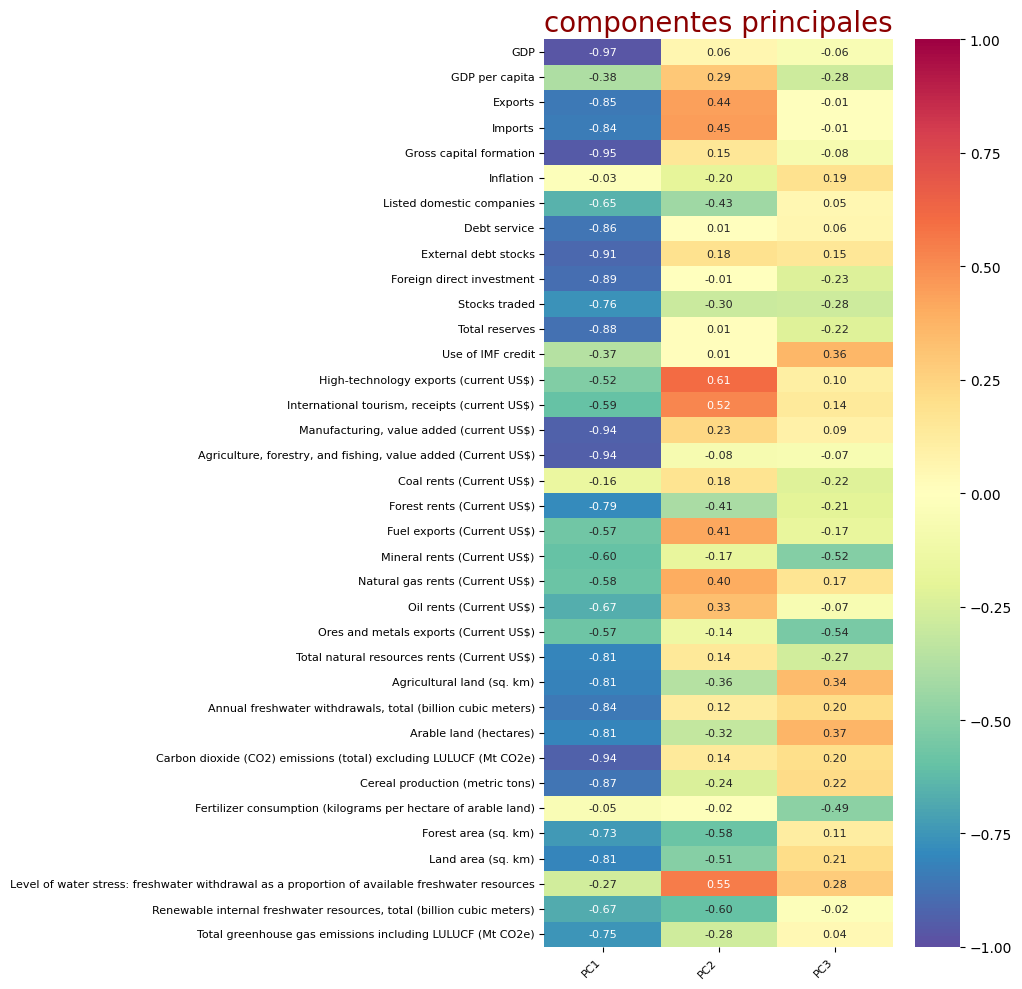

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(10, 10))  # ancho alto
sns.heatmap(
    componentes,
    annot=True,
    fmt=".2f",
    cmap="Spectral_r",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 8}  # tamaño de letra de los valores anotados
)

plt.title('componentes principales', color='darkred', size=20)
plt.xticks(fontsize=8, rotation=45, ha='right')  # tamaño y orientación etiquetas eje X
plt.yticks(fontsize=8)  # tamaño etiquetas eje Y
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()  # asegura que todo encaje bien
plt.show()


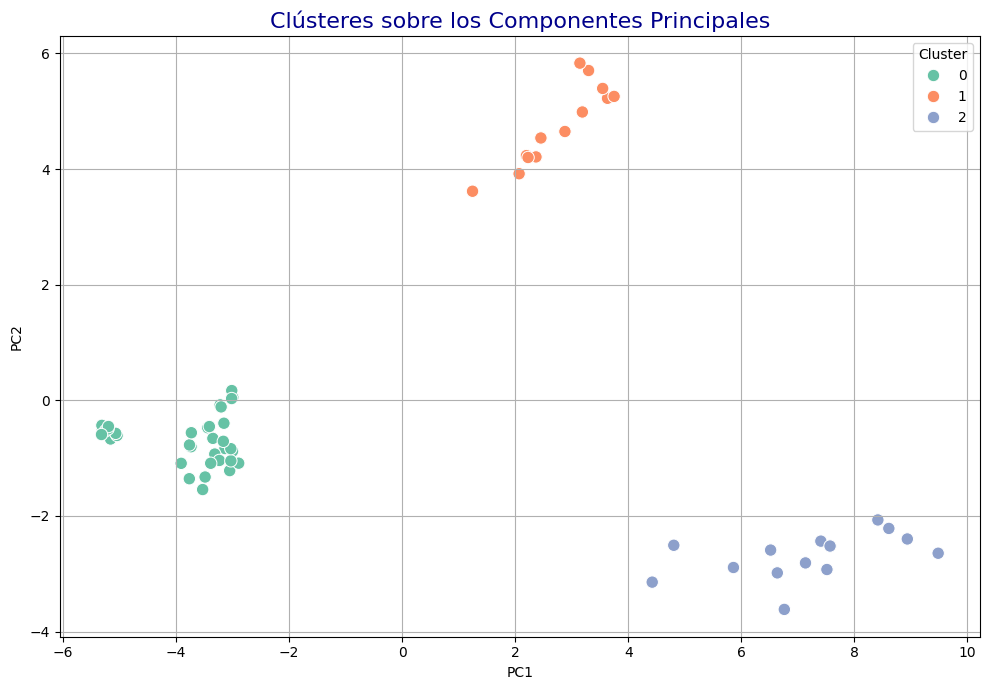

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Seleccionamos solo las variables numéricas y las estandarizamos
X = Latam_Economico_ambiental_num[columnas].dropna()
X_std = StandardScaler().fit_transform(X)

# 2. Aplicamos PCA
pca = PCA(n_components=3)  # podés ajustar a 2 o 3
X_pca = pca.fit_transform(X_std)

# 3. Aplicamos KMeans sobre los componentes
kmeans = KMeans(n_clusters=3, random_state=42)  # podés probar otros valores de k
clusters = kmeans.fit_predict(X_pca)

# 4. Creamos un DataFrame con los componentes y el cluster
df_clusters = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_clusters['Cluster'] = clusters

# 5. Visualizamos los clusters en los primeros dos componentes
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_clusters, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=80)
plt.title('Clústeres sobre los Componentes Principales', fontsize=16, color='darkblue')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


## probamos otra cosa para componentes principales

In [ ]:
# Seleccionamos columnas numéricas y completamos NaN con la media
df = Latam_Economico_ambiental.copy()
X = df.select_dtypes(include='number').copy()
X.fillna(X.mean(), inplace=True)

# Estandarizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=5)
pca.fit(X_scaled)

# Cargas factoriales (loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'F{i+1}' for i in range(pca.n_components_)],
    index=X.columns
).round(3)

# Ordenamos cada columna por magnitud
sorted_loadings = pd.DataFrame()
for factor in loadings.columns:
    sorted_factor = loadings[[factor]].reindex(loadings[factor].abs().sort_values(ascending=False).index)
    sorted_loadings = pd.concat([sorted_loadings, sorted_factor], axis=1)

# Mostramos tabla final
print(sorted_loadings)


                                                       F1     F2     F3  \
GDP                                                 0.225 -0.026  0.029   
Gross capital formation                             0.221 -0.070  0.026   
Agriculture, forestry, and fishing, value added...  0.218  0.041  0.055   
Manufacturing, value added (current US$)            0.217 -0.104 -0.085   
Carbon dioxide (CO2) emissions (total) excludin...  0.216 -0.065 -0.149   
External debt stocks                                0.211 -0.099 -0.051   
Total reserves                                      0.207 -0.008  0.140   
Foreign direct investment                           0.206  0.003  0.137   
Cereal production (metric tons)                     0.200  0.114 -0.086   
Debt service                                        0.199 -0.010  0.018   
Exports                                             0.196 -0.212 -0.028   
Imports                                             0.195 -0.214 -0.030   
Annual freshwater withdra

In [ ]:
sorted_loadings

,F1,F2,F3,F4,F5
GDP,0.225,-0.026,0.029,-0.026,-0.028
Gross capital formation,0.221,-0.070,0.026,-0.016,-0.070
"Agriculture, forestry, and fishing, value added (Current US$)",0.218,0.041,0.055,-0.009,0.045
"Manufacturing, value added (current US$)",0.217,-0.104,-0.085,-0.042,-0.046
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),0.216,-0.065,-0.149,0.027,0.004
External debt stocks,0.211,-0.099,-0.051,-0.122,0.075
Total reserves,0.207,-0.008,0.140,-0.082,-0.076
Foreign direct investment,0.206,0.003,0.137,-0.073,-0.069
Cereal production (metric tons),0.200,0.114,-0.086,-0.045,0.235
Debt service,0.199,-0.010,0.018,-0.097,0.082


In [ ]:
import plotly.express as px

# Hacemos una copia del dataframe para no modificar el original
df_plot = correlaciones_Latam_Economico_ambiental_num.copy()

# Lista de columnas que vas a usar
columns = [
    'GDP', 'Exports', 'Arable land (hectares)',
    'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)',
    'Forest area (sq. km)', 'Land area (sq. km)',
    'Level of water stress: freshwater withdrawal as a proportion of available freshwater resources'
]

# Renombrar columnas truncándolas a 15 caracteres
short_names = {col: col[:23] for col in columns}
df_plot = df_plot.rename(columns=short_names)

# Scatter matrix con nombres truncados
fig = px.scatter_matrix(
    df_plot,
    dimensions=[short_names[col] for col in columns],
   
    width=1200,
    height=1200
)

# Cambiar el tamaño de fuente
fig.update_layout(font=dict(size=9))

fig.show()


## Análisis Factorial


In [ ]:
# Eliminar filas o columnas con NaN
df= Latam_Economico_ambiental_num

df_clean = df.dropna()  # o df.fillna(method='ffill') si preferís imputar

# Verificar columnas con valores constantes
constant_cols = [col for col in df_clean.columns if df_clean[col].nunique() <= 1]
print("Columnas constantes:", constant_cols)

# Eliminar columnas constantes
df_clean = df_clean.drop(columns=constant_cols)
df_clean

Columnas constantes: []


,GDP,GDP per capita,Exports,Imports,Gross capital formation,Inflation,Listed domestic companies,Debt service,External debt stocks,Foreign direct investment,...,"Annual freshwater withdrawals, total (billion cubic meters)",Arable land (hectares),Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),Cereal production (metric tons),Fertilizer consumption (kilograms per hectare of arable land),Forest area (sq. km),Land area (sq. km),Level of water stress: freshwater withdrawal as a proportion of available freshwater resources,"Renewable internal freshwater resources, total (billion cubic meters)",Total greenhouse gas emissions including LULUCF (Mt CO2e)
87,1.397114e+12,7409.691307,1.862029e+11,1.671639e+11,2.768987e+11,3.641273,395.0,5.500902e+10,2.384445e+11,4.457949e+10,...,62.220000,49537000.0,393.0476,69441634.00,233.142411,5234330.7,8358140.0,2.941844,5661.0,1842.17700
88,1.695855e+12,8908.331766,2.295170e+11,2.327318e+11,3.666334e+11,5.678594,383.0,5.654325e+10,2.629572e+11,5.071640e+10,...,66.401000,50159000.0,412.7003,79745466.44,214.677601,5194822.8,8358140.0,3.139527,5661.0,1975.44190
89,1.666996e+12,8678.659225,1.808920e+11,1.876139e+11,3.133309e+11,4.888035,377.0,4.452666e+10,2.816511e+11,3.148093e+10,...,70.585875,50782000.0,385.4613,70914790.87,148.486384,5155314.9,8358140.0,3.337394,5661.0,1335.46770
90,2.208838e+12,11403.282128,2.400031e+11,2.629973e+11,4.815558e+11,5.038727,373.0,4.588147e+10,3.523644e+11,8.238993e+10,...,74.770750,51405000.0,439.7694,75160152.06,202.796765,5115807.0,8358140.0,3.535260,5661.0,1349.93640
91,2.616156e+12,13396.624357,3.030166e+11,3.231448e+11,5.710094e+11,6.636450,366.0,5.907017e+10,4.040461e+11,1.024272e+11,...,72.315625,52027000.0,463.5013,77586276.00,251.427319,5100415.2,8358140.0,3.419178,5661.0,1465.89980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516,1.918981e+11,6217.036000,4.336957e+10,4.373075e+10,4.225848e+10,3.557177,217.0,7.788910e+09,6.961278e+10,6.805248e+09,...,32.581609,3798172.0,57.4912,5283994.69,118.478110,730102.8,1280000.0,6.069599,1641.0,190.61906
517,2.110080e+11,6736.166937,5.216090e+10,4.809648e+10,4.370358e+10,2.994900,218.0,1.109614e+10,6.760358e+10,7.413410e+09,...,34.958686,3756825.0,55.2061,5140707.27,143.599654,728347.8,1280000.0,6.512423,1641.0,164.51010
518,2.225970e+11,6978.491215,5.607705e+10,5.217515e+10,4.743804e+10,1.509154,209.0,7.290511e+09,6.676927e+10,5.872657e+09,...,37.335762,3814351.0,55.3373,5654930.21,113.533382,726760.4,1280000.0,6.955246,1641.0,163.69900
519,2.283460e+11,7037.008037,5.489230e+10,5.230132e+10,4.757278e+10,2.252122,196.0,6.688529e+09,6.424728e+10,4.775377e+09,...,38.550000,3580226.0,58.1595,5284137.61,141.662032,725032.0,1280000.0,7.181446,1641.0,192.98005


In [ ]:
print(df_clean.columns)

Index(['GDP', 'GDP per capita', 'Exports', 'Imports',
       'Gross capital formation', 'Inflation', 'Listed domestic companies',
       'Debt service', 'External debt stocks', 'Foreign direct investment',
       'Stocks traded', 'Total reserves', 'Use of IMF credit',
       'High-technology exports (current US$)',
       'International tourism, receipts (current US$)',
       'Manufacturing, value added (current US$)',
       'Agriculture, forestry, and fishing, value added (Current US$)',
       'Coal rents (Current US$)', 'Forest rents (Current US$)',
       'Fuel exports (Current US$)', 'Mineral rents (Current US$)',
       'Natural gas rents (Current US$)', 'Oil rents (Current US$)',
       'Ores and metals exports (Current US$)',
       'Total natural resources rents (Current US$)',
       'Agricultural land (sq. km)',
       'Annual freshwater withdrawals, total (billion cubic meters)',
       'Arable land (hectares)',
       'Carbon dioxide (CO2) emissions (total) excluding LUL

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)
df_scaled

array([[ 7.67960769e-01, -5.10566414e-01,  1.63416354e-01, ...,
        -5.71106515e-01,  1.74130606e+00,  2.27325461e+00],
       [ 1.15483988e+00,  9.25725105e-02,  4.48185718e-01, ...,
        -5.55396531e-01,  1.74130606e+00,  2.50702683e+00],
       [ 1.11746696e+00,  1.39099618e-04,  1.28499727e-01, ...,
        -5.39671987e-01,  1.74130606e+00,  1.38438923e+00],
       ...,
       [-7.53078810e-01, -6.84106077e-01, -6.92097250e-01, ...,
        -2.52159432e-01, -2.66064135e-01, -6.71118015e-01],
       [-7.45633667e-01, -6.60555550e-01, -6.99886426e-01, ...,
        -2.34183255e-01, -2.66064135e-01, -6.19753432e-01],
       [-7.80517095e-01, -1.02424925e+00, -7.56065738e-01, ...,
        -2.34183255e-01, -2.66064135e-01, -6.39320040e-01]],
      shape=(63, 36))

In [ ]:
from factor_analyzer import FactorAnalyzer

fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(df_scaled)

loadings = pd.DataFrame(fa.loadings_, index=df_clean.columns)
loadings


C:\Users\lulaz\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



,0,1,2
GDP,0.838631,0.512918,0.125925
GDP per capita,0.219096,0.371714,0.060135
Exports,0.321724,0.941529,0.046621
Imports,0.328993,0.936870,0.081741
Gross capital formation,0.742680,0.592645,0.170584
Inflation,0.454096,0.161884,0.157745
Listed domestic companies,0.887148,0.111360,-0.191735
Debt service,0.703605,0.494381,-0.009990
External debt stocks,0.549725,0.771256,-0.013291
Foreign direct investment,0.870192,0.362564,0.113218


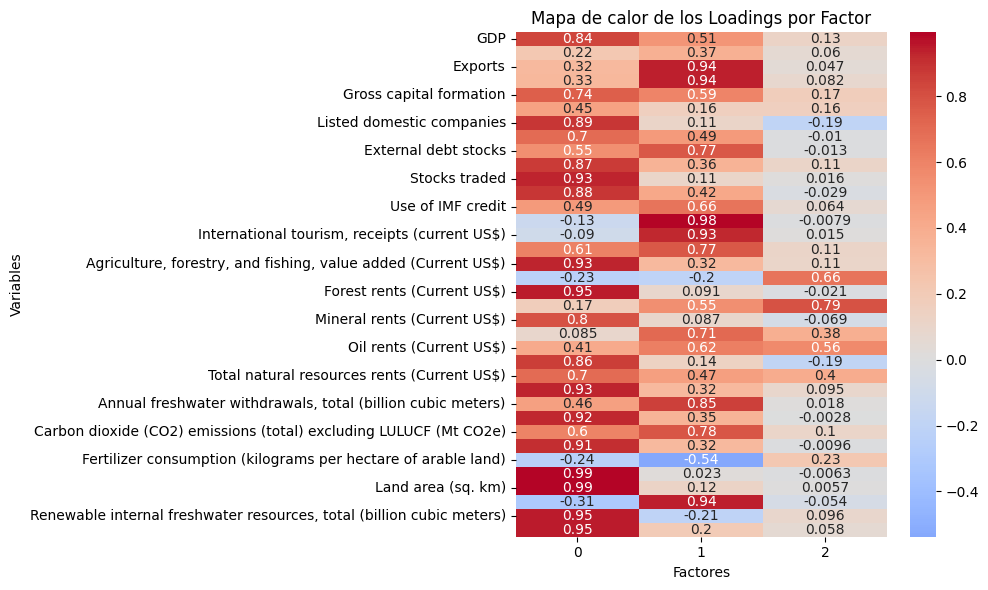

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)

plt.title("Mapa de calor de los Loadings por Factor")
plt.xlabel("Factores")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()
